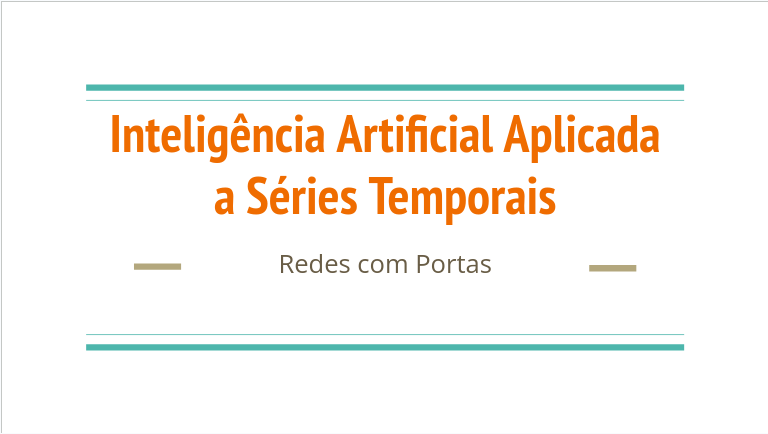

## Bibliotecas

In [35]:
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import datetime

## Introdução

Na aula passada, apresentamos as redes neurais recorrentes, que processam um elemento da sequência de cada vez. Agora, vamos estudar uma variante popular dessas redes, que são as **redes recorrentes com portas**.

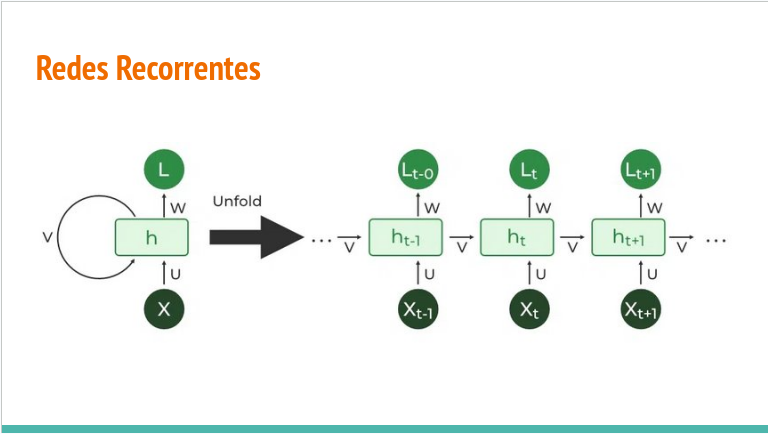

## Redes Recorrentes com Portas

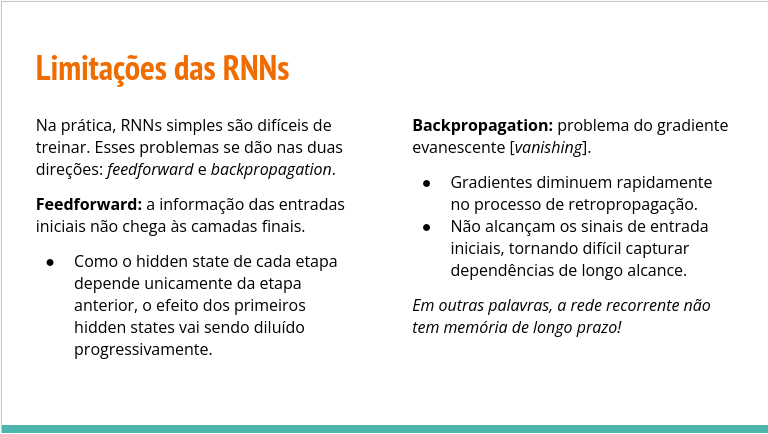

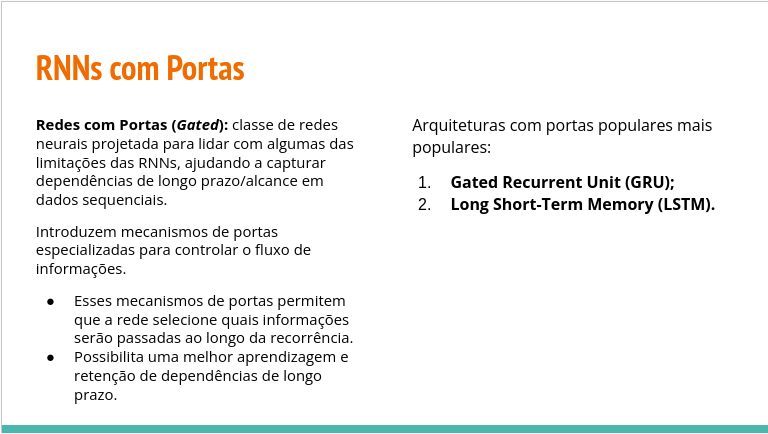

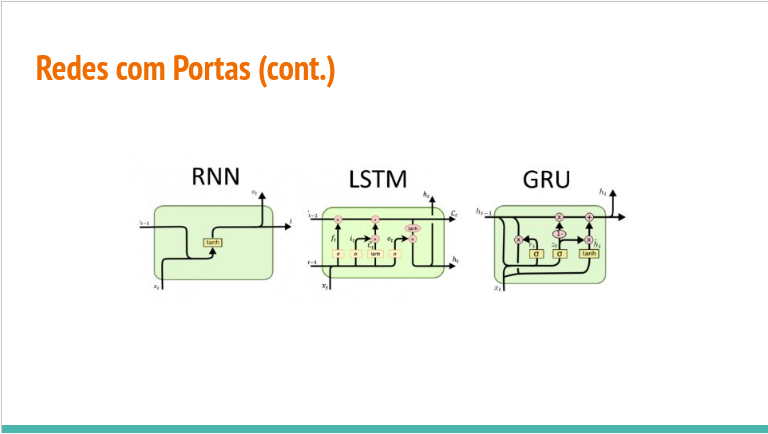

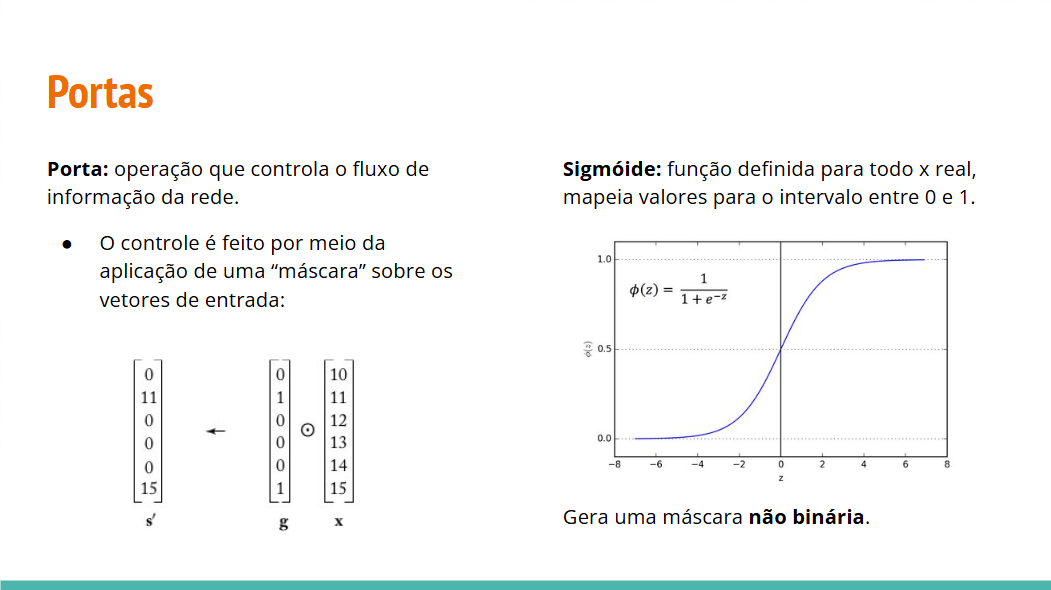

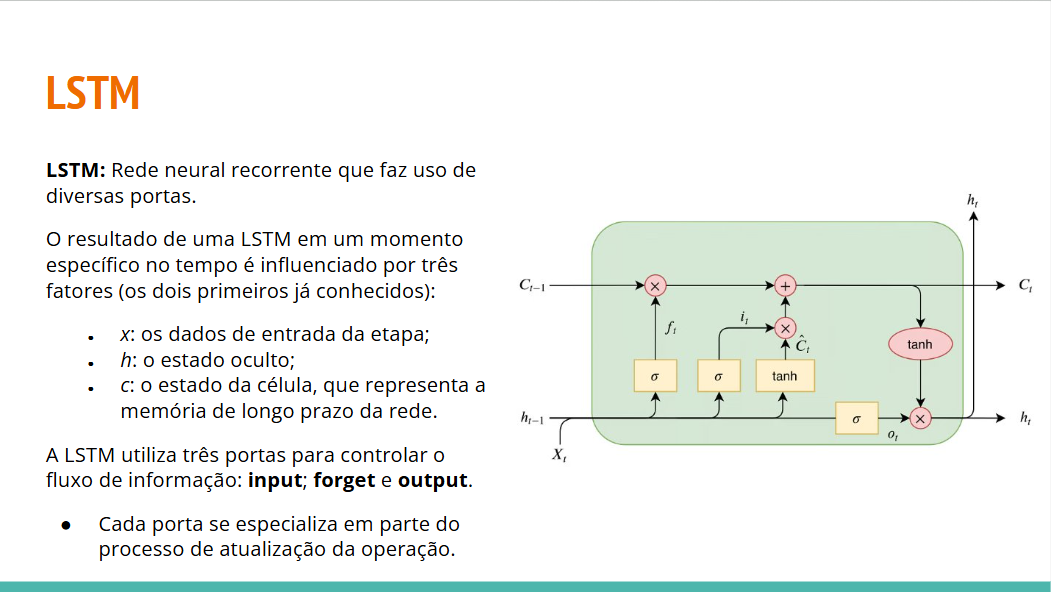

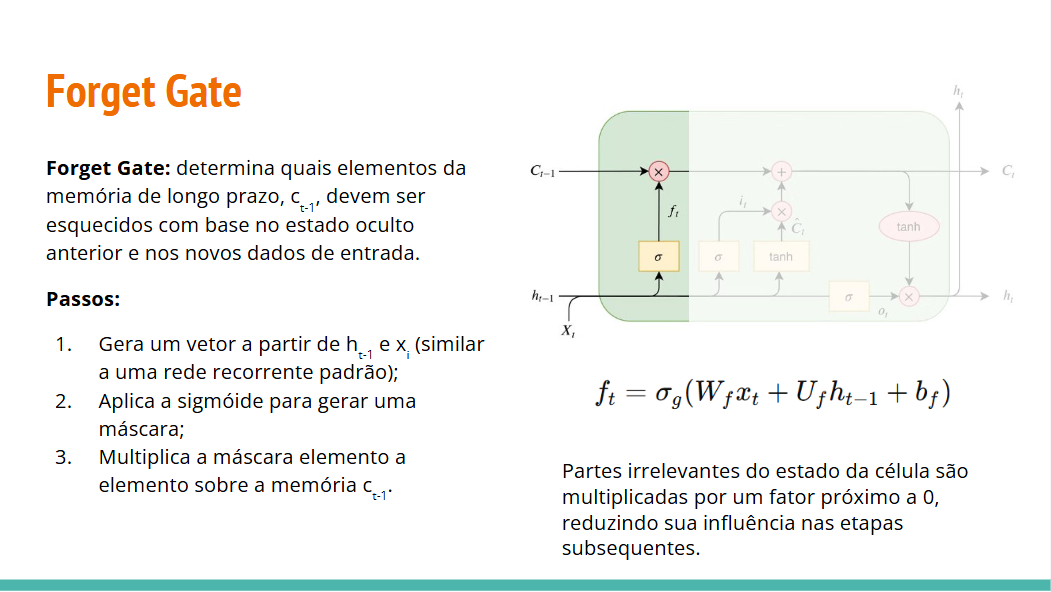

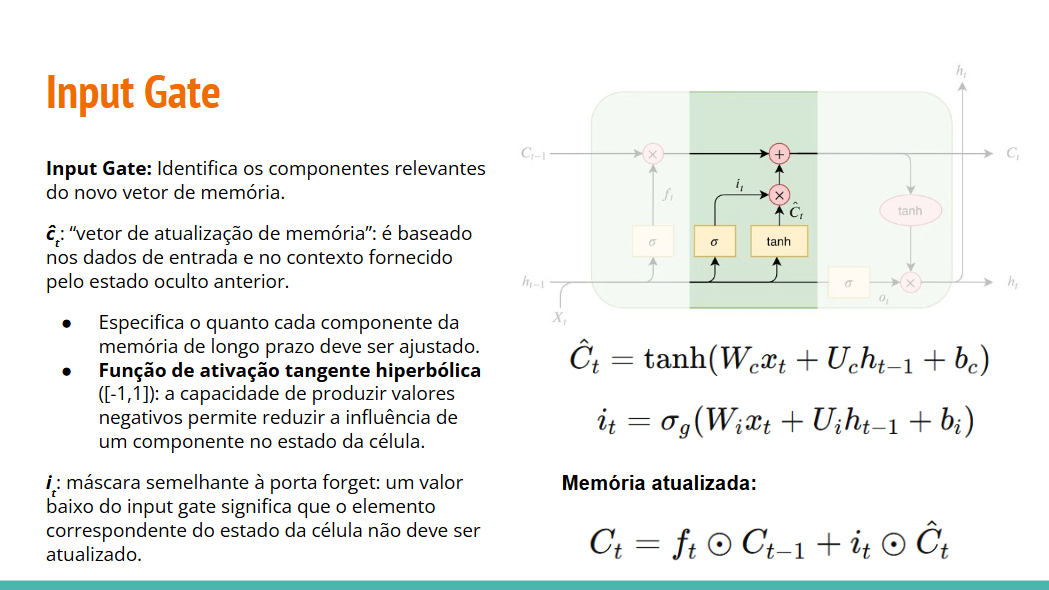

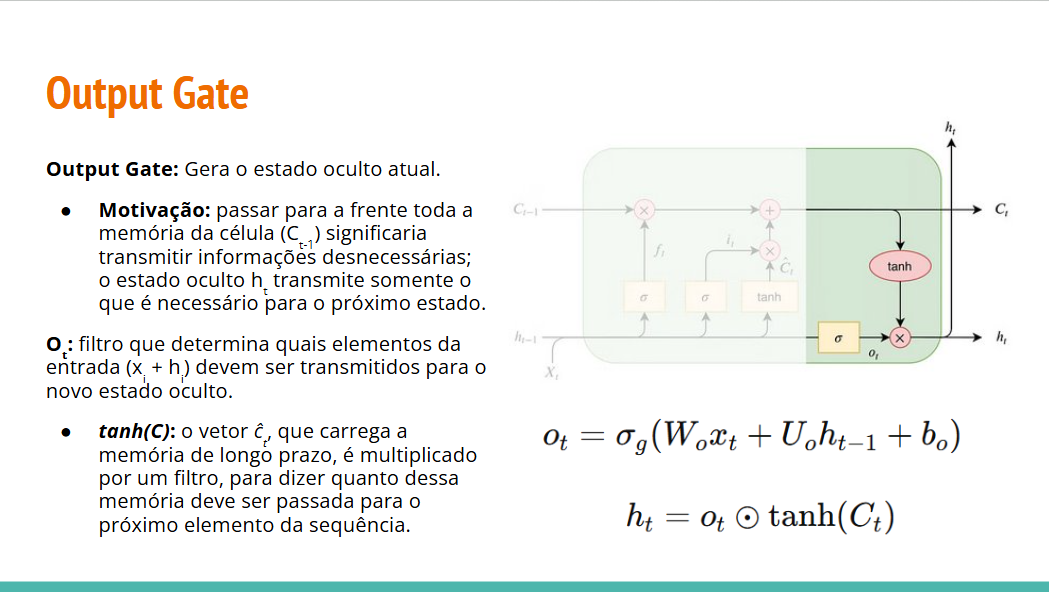

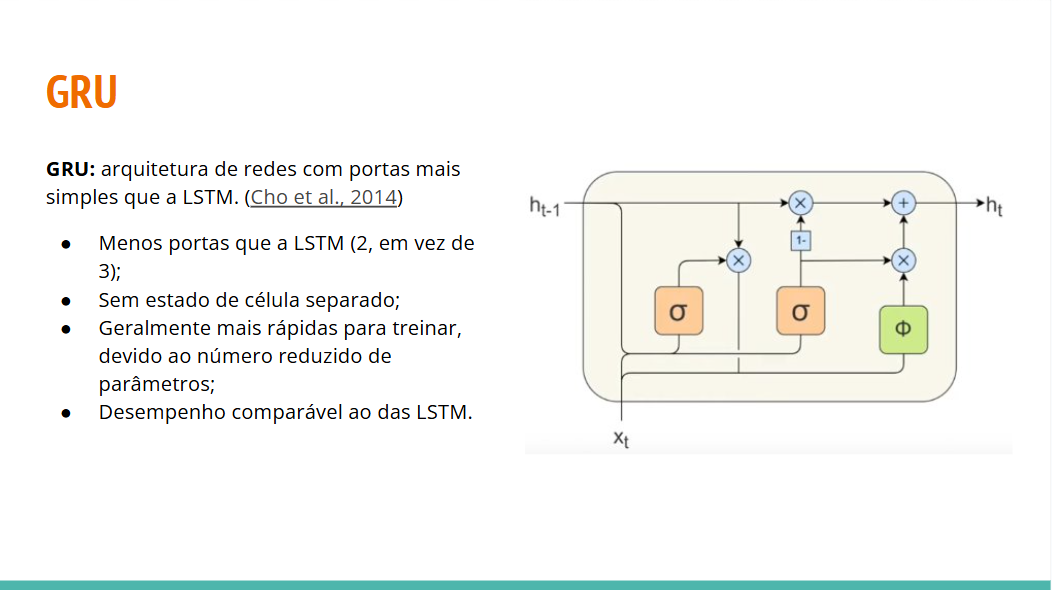

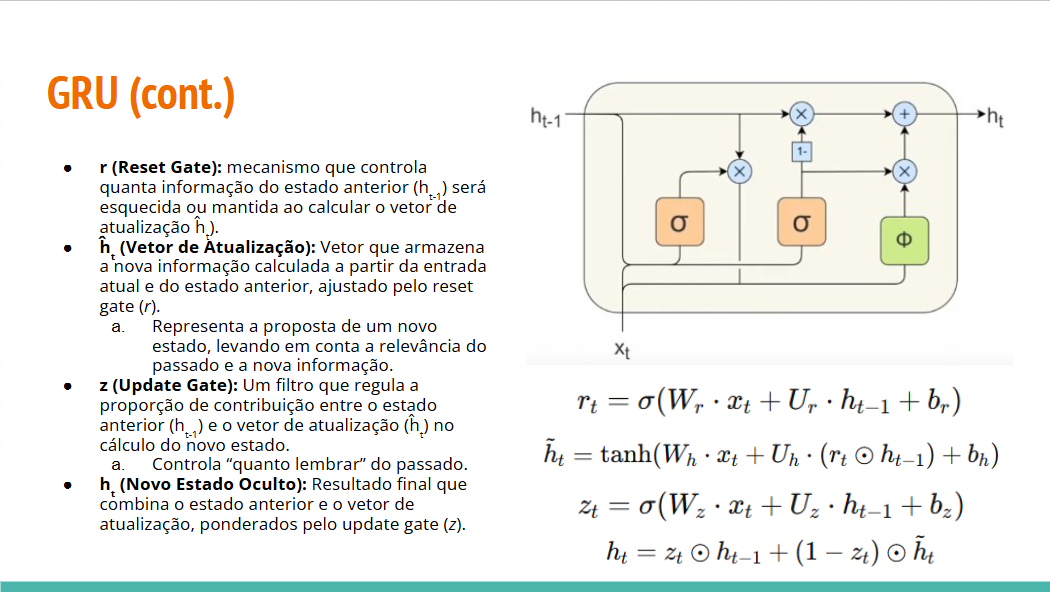

## Conjunto de dados

Vamos utilizar novamente o conjunto de dados "The weather dataset" (https://www.bgc-jena.mpg.de/wetter/), criado pelo Max Planck Institute for Biogeochemistry.

Esse conjunto de dados contém 14 variáveis, tais como temperatura do ar, pressão atmosférica e humidade. Os dados são coletados a cada 10 minutos, iniciando em 2003. Por conveniência são usados somente os dados coletados entre 2009 e 2016, que foram preparados por François Chollet para seu livro "Deep Learning with Python".

### Carregamento

Os dados podem ser carregados diretamente do TensorFlow/Keras.

In [36]:
zip_path = tf.keras.utils.get_file(
    origin='https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip',
    fname='jena_climate_2009_2016.csv.zip',
    extract=True)

csv_path, _ = os.path.splitext(zip_path)

Os dados estão em um arquivo tipo CSV, então vamos carregá-lo em um dataframe pandas.

In [37]:
# carrega dados em uma dataframe pandas
df = pd.read_csv(csv_path)

print(df.shape)

df.head()

(420551, 15)


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


Descrição das variáveis

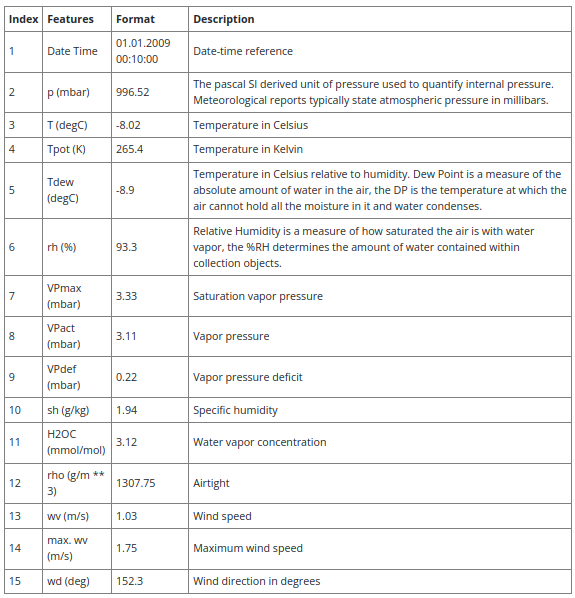

**Referência:** https://keras.io/examples/timeseries/timeseries_weather_forecasting/

Os dados são amostrados a cada 10 minutos. Aqui, utilizaremos os dados amostrados a cada hora. Para isso, devemos realizar uma subamostragem dos dados de intervalos de 10 minutos para 1 hora. Além disso, vamos separar a coluna de data-hora.

In [38]:
# Pega 1 dado a cada 6 (10 minutos original, para 1 hora)
df = df[5::6]

# Separa coluna da data-hora
date_time = pd.to_datetime(df.pop('Date Time'), format='%d.%m.%Y %H:%M:%S')

print(df.shape)

df.head()

(70091, 14)


,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
5,996.50,-8.05,265.38,-8.78,94.4,3.33,3.14,0.19,1.96,3.15,1307.86,0.21,0.63,192.7
11,996.62,-8.88,264.54,-9.77,93.2,3.12,2.90,0.21,1.81,2.91,1312.25,0.25,0.63,190.3
17,996.84,-8.81,264.59,-9.66,93.5,3.13,2.93,0.20,1.83,2.94,1312.18,0.18,0.63,167.2
23,996.99,-9.05,264.34,-10.02,92.6,3.07,2.85,0.23,1.78,2.85,1313.61,0.10,0.38,240.0
29,997.46,-9.63,263.72,-10.65,92.2,2.94,2.71,0.23,1.69,2.71,1317.19,0.40,0.88,157.0


Abaixo, plotamos uma série de gráficos da evolução de algumas features dos dados em função do tempo. As variáveis escolhidas foram 'T (degC)', 'p (mbar)' e 'rho (g/m**3)', que representam, respectivamente, temperatura em graus Celsius, pressão em mbar e densidade em gramas por metro cúbico.

O primeiro gráfico mostra a série completa. O segundo gráfico apresenta os primeiros 480 valores. Considerando a resolução de 1 hora por ponto de dados, isso corresponde às primeiras 480 horas, ou 20 dias.

O objetivo é destacar diferentes aspectos dos dados ao longo do tempo, especialmente para verificar comportamentos ou tendências a longo prazo versus análises mais detalhadas de períodos mais curtos.

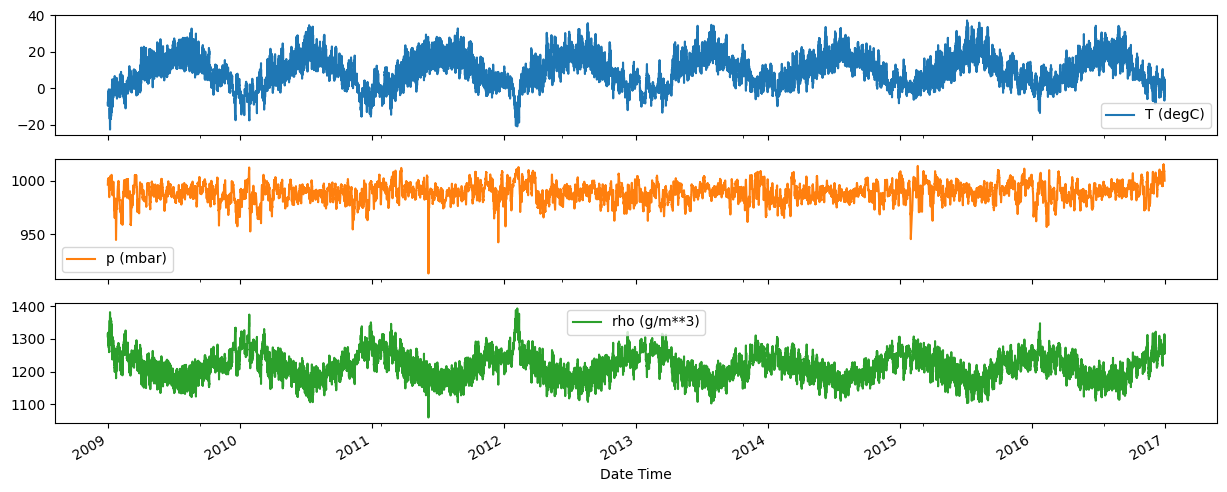

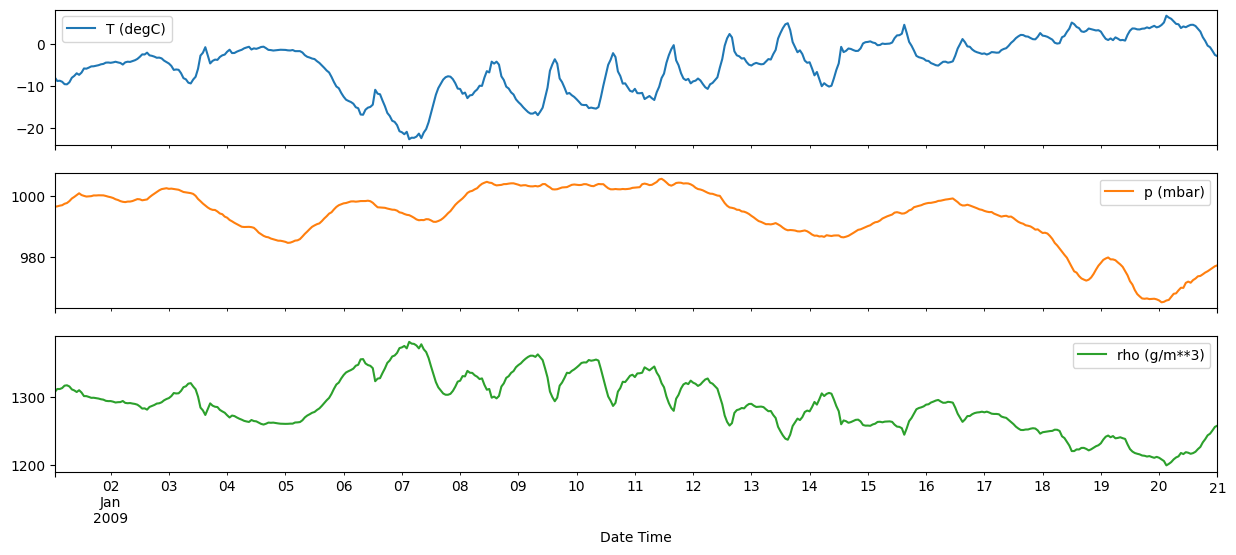

In [39]:
plot_cols = ['T (degC)', 'p (mbar)', 'rho (g/m**3)']
plot_features = df[plot_cols]
plot_features.index = date_time
_ = plot_features.plot(subplots=True, figsize = (15,6))

plot_features = df[plot_cols][:480]
plot_features.index = date_time[:480]
_ = plot_features.plot(subplots=True, figsize = (15,6))

### Pré-processamento

Antes de desenvolver o modelo é importante verificar e entender os dados, deixando-os em um formato adequado para que possam alimentar a rede neural.

Primeiramente, vamos calcular as estatísticos básicas do conjunto de dados.

In [40]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
p (mbar),70091.0,989.212842,8.358886,913.60,984.20,989.57,994.720,1015.29
T (degC),70091.0,9.450482,8.423384,-22.76,3.35,9.41,15.480,37.28
Tpot (K),70091.0,283.493086,8.504424,250.85,277.44,283.46,289.530,311.21
Tdew (degC),70091.0,4.956471,6.730081,-24.80,0.24,5.21,10.080,23.06
rh (%),70091.0,76.009788,16.474920,13.88,65.21,79.30,89.400,100.00
VPmax (mbar),70091.0,13.576576,7.739883,0.97,7.77,11.82,17.610,63.77
VPact (mbar),70091.0,9.533968,4.183658,0.81,6.22,8.86,12.360,28.25
VPdef (mbar),70091.0,4.042536,4.898549,0.00,0.87,2.19,5.300,46.01
sh (g/kg),70091.0,6.022560,2.655812,0.51,3.92,5.59,7.800,18.07
H2OC (mmol/mol),70091.0,9.640437,4.234862,0.81,6.29,8.96,12.490,28.74


Como podemos observar, há uma disparidade grande em relação a médias e desvios padrão. Essas diferenças de magnitude entre features impactam enormemente o desempenho de redes neurais. Precisaremos depois normalizar esses dados.

#### Correção de dados

Podemos ver que não há dados faltantes no dataset.

In [41]:
df.isnull().sum()

,0
p (mbar),0
T (degC),0
Tpot (K),0
Tdew (degC),0
rh (%),0
VPmax (mbar),0
VPact (mbar),0
VPdef (mbar),0
sh (g/kg),0
H2OC (mmol/mol),0


Os valores mínimos das colunas `wv` e `max.wv` (velocidade do vento) possuem valores mínimos iguais a -9999. Certamente isso é um erro, pois a velocidade do vento deve ser maior ou igual a zero. Para resolver esse problema, vamos trocar esses valores por 0.

In [42]:
# Troca valores negativos da coluna wv por 0
wv = df['wv (m/s)']
bad_wv = wv == -9999.0
wv[bad_wv] = 0.0

# Troca valores negativos da coluna max.wv por 0
max_wv = df['max. wv (m/s)']
bad_max_wv = max_wv == -9999.0
max_wv[bad_max_wv] = 0.0

# Verifica valores mínimos no dataframe
df['wv (m/s)'].min()

0.0

#### Direção do vento

A última coluna dos dados 'wd (deg)' fornece a direção do vento em graus. Ângulos não são adequados para serem usados em uma rede neural, em função da discontinuidade existente entre 0 e 360 graus, que de fato representam o mesmo ângulo. P. ex., os ângulos de 5º e 357º estão em extremos opostos do intervalo 0-360, apesar de estarem a menos de 10º de distância.

Vamos visualizar a distribuição dos dados de vento (velocidade versus direção).

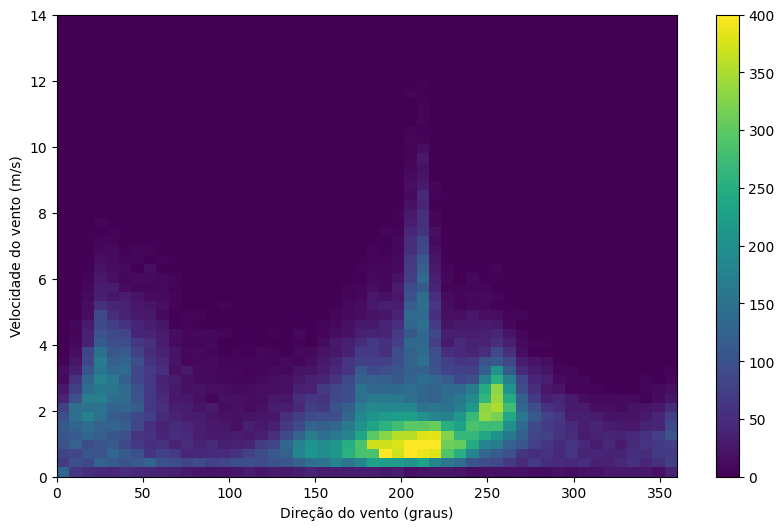

In [43]:
plt.figure(figsize=(10,6))
plt.hist2d(df['wd (deg)'], df['wv (m/s)'], bins=(50, 50), vmax=400)
plt.colorbar()
plt.xlabel('Direção do vento (graus)')
plt.ylabel('Velocidade do vento (m/s)')
plt.show()

É mais fácil para o modelo interpretar os dados de velocidade do vento, se convertemos a velocidade e a direção do vento em um vetor que contém as coordenadas da velocidade do vento em duas direções.

In [44]:
# Separa colunas de velocidade do vento
wv = df.pop('wv (m/s)')
max_wv = df.pop('max. wv (m/s)')

# Converte angulo de graus para radianos
wd_rad = df.pop('wd (deg)')*np.pi / 180

# Calcula as componentes do vetor velocidade do vento
df['Wx'] = wv*np.cos(wd_rad)
df['Wy'] = wv*np.sin(wd_rad)

# Calcula as componentes do vetor velocidade máxima do vento
df['max Wx'] = max_wv*np.cos(wd_rad)
df['max Wy'] = max_wv*np.sin(wd_rad)

O gráfico abaixo mostra as coordenadas do vetor do vento. Observe que agora não existe discontinuidade entre as medidas e podemos verificar que a distribuição da velocidade do vento é em torno de 0.

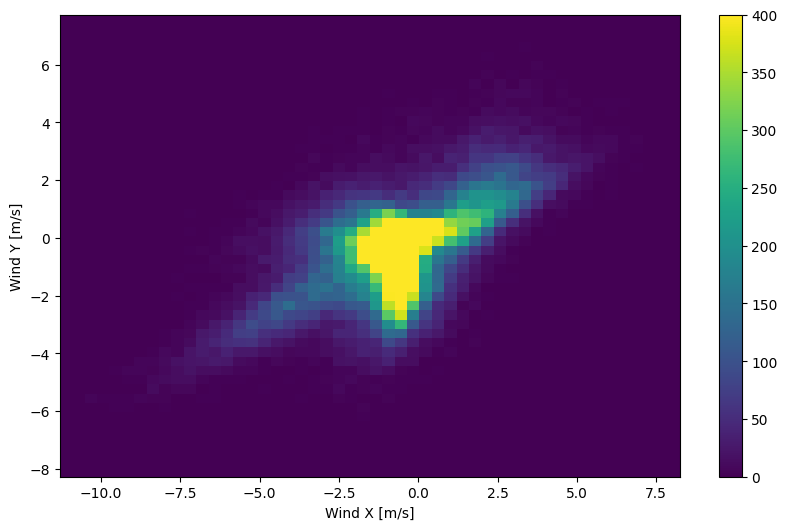

In [45]:
plt.figure(figsize=(10,6))
plt.hist2d(df['Wx'], df['Wy'], bins=(50, 50), vmax=400)
plt.colorbar()
plt.xlabel('Wind X [m/s]')
plt.ylabel('Wind Y [m/s]')
plt.gca()
plt.axis('tight')
plt.show()

#### Data-hora

A informação da data-hora é muito útil porque a temperatura varia tanto em função das horas do dia quanto em função dos meses do ano.

A primeira operação que devemos realizar é converter a informação de data-hora para segundos. Para isso, usamos a função 'timestamp' da biblioteca Datetime.

Nessa escala de tempo de segundos, o instante de tempo igual a 0 representa o ano 0, dia 0, hora 0, minuto 0 e segundo 0.

In [46]:
# Convete data-hora para segundos
timestamp_seg = date_time.map(datetime.datetime.timestamp)
timestamp_seg

,Date Time
5,1.230772e+09
11,1.230775e+09
17,1.230779e+09
23,1.230782e+09
29,1.230786e+09
...,...
420521,1.483211e+09
420527,1.483215e+09
420533,1.483219e+09
420539,1.483222e+09


A informação da data-hora em segundos não é muito útil porque a escala de tempo de variação da temperatura é de horas (variação diária) e de meses (variação anual).

Existem algumas formas de tratar periodicidade em séries temporais e todas elas necessitam de uma escala de tempo adequada aos dados.

No caso da temperatura, vamos usar duas escalas de tempo: uma para representar os dias e outra para os anos. Ambas as escalas vão estar em unidades de horas, que é o período de amostragem utilizado ($T_a = 1$ hora).

In [47]:
# Quantidade de segundos em um dia
day = 24*60*60

# Quantidade de segundos em um ano
year = (365.2425)*day

# Escala de tempo diária
df['Day sin'] = np.sin(timestamp_seg * (2 * np.pi / day))

# Escala de tempo anual
df['Year sin'] = np.sin(timestamp_seg * (2 * np.pi / year))

**Constantes:**

**day:** A variável day é definida como o número total de segundos em um dia. Isto é calculado multiplicando 24 horas por 60 minutos por hora e por 60 segundos por minuto, resultando em 86.400 segundos.

**year:** A variável year calcula o total de segundos em um ano. Para maior precisão, considera-se o ano como tendo 365,2425 dias (o que leva em conta anos bissextos), e multiplica-se esse número pelo número de segundos em um dia (day). O resultado é o total de segundos em um ano médio.

Como vocês podem ver no código, também aplicamos operações trigonométricas aos dados de tempo.

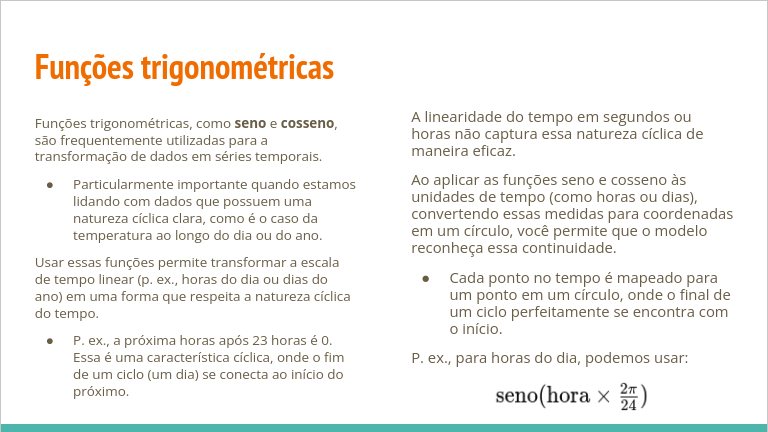

A principal diferença entre o seno e o cosseno é a em relação à fase inicial. O cosseno começa com seu valor máximo em t=0 (cos(0) = 1), enquanto o seno começa em zero (sin(0) = 0).

Se a característica ou o comportamento que você está modelando tem um pico ou um valor significativo em t=0, o cosseno pode ser mais apropriado. Se o comportamento começa de um ponto neutro ou zero, então o seno pode ser mais relevante.

Voltando à transformação realizada com a variável tempo, temos:

**Escala de tempo diária:** Cada timestamp é multiplicado por 2π/day​. Isso normaliza os segundos para uma escala de 0 a 2π ao longo de um dia inteiro, representando um ciclo completo de 24 horas em um círculo.

**Escala de tempo anual:** Multiplicar cada timestamp por 2π/year​ mapeia o tempo para uma escala de 0 a 2π ao longo de um ano inteiro.

In [48]:
df.head()

,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),Wx,Wy,max Wx,max Wy,Day sin,Year sin
5,996.50,-8.05,265.38,-8.78,94.4,3.33,3.14,0.19,1.96,3.15,1307.86,-0.204862,-0.046168,-0.614587,-0.138503,0.258819,0.010049
11,996.62,-8.88,264.54,-9.77,93.2,3.12,2.90,0.21,1.81,2.91,1312.25,-0.245971,-0.044701,-0.619848,-0.112645,0.500000,0.010766
17,996.84,-8.81,264.59,-9.66,93.5,3.13,2.93,0.20,1.83,2.94,1312.18,-0.175527,0.039879,-0.614344,0.139576,0.707107,0.011483
23,996.99,-9.05,264.34,-10.02,92.6,3.07,2.85,0.23,1.78,2.85,1313.61,-0.050000,-0.086603,-0.190000,-0.329090,0.866025,0.012199
29,997.46,-9.63,263.72,-10.65,92.2,2.94,2.71,0.23,1.69,2.71,1317.19,-0.368202,0.156292,-0.810044,0.343843,0.965926,0.012916


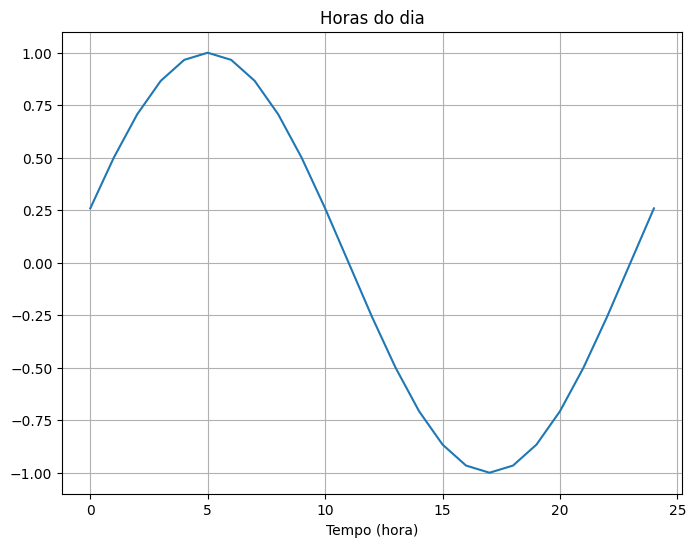

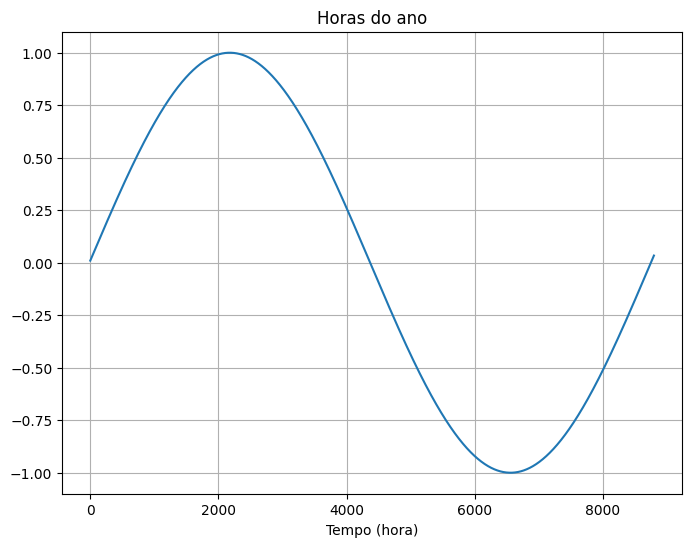

In [49]:
plt.figure(figsize=(8,6))
plt.plot(np.array(df['Day sin'])[:25])
plt.xlabel('Tempo (hora)')
plt.title('Horas do dia')
plt.grid()
plt.show()

plt.figure(figsize=(8,6))
plt.plot(np.array(df['Year sin'])[:8800])
plt.xlabel('Tempo (hora)')
plt.title('Horas do ano')
plt.grid()
plt.show()

Na escala de tempo diária, um período das funções seno e cosseno representa um dia; na escala de tempo anual, um período representa um ano.

As duas escalas de tempo, diária e anual fornecem ao modelo as características de frequências mais importantes que a distância em tempo em relação ao início da série. Como já sabemos quais as frequências mais importantes associadas à variação de temperatura, escolhemos essas duas escalas para trabalhar.

Vamos visualizar como ficaram os dados.

In [50]:
df.head()

,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),Wx,Wy,max Wx,max Wy,Day sin,Year sin
5,996.50,-8.05,265.38,-8.78,94.4,3.33,3.14,0.19,1.96,3.15,1307.86,-0.204862,-0.046168,-0.614587,-0.138503,0.258819,0.010049
11,996.62,-8.88,264.54,-9.77,93.2,3.12,2.90,0.21,1.81,2.91,1312.25,-0.245971,-0.044701,-0.619848,-0.112645,0.500000,0.010766
17,996.84,-8.81,264.59,-9.66,93.5,3.13,2.93,0.20,1.83,2.94,1312.18,-0.175527,0.039879,-0.614344,0.139576,0.707107,0.011483
23,996.99,-9.05,264.34,-10.02,92.6,3.07,2.85,0.23,1.78,2.85,1313.61,-0.050000,-0.086603,-0.190000,-0.329090,0.866025,0.012199
29,997.46,-9.63,263.72,-10.65,92.2,2.94,2.71,0.23,1.69,2.71,1317.19,-0.368202,0.156292,-0.810044,0.343843,0.965926,0.012916


#### Divisão dos dados

Vamos dividir os dados nos conjuntos de treinamento, validação e teste na seguinte proporção: 70%, 15% e 15%.

No caso de séries temporais não se deve embaralhar os dados por dois motivos:

1. Assegurar que a sequência dos dados da série é mantida;
2. Possibilitar usar amostras da série que ainda serão coletadas para o conjunto de teste.

In [51]:
# Nomes das colunas do DataFrame
column_indices = {name: i for i, name in enumerate(df.columns)}

# Número de amostras na séria
n = len(df)

# Divisão dos dados
train_df = df[0:int(n*0.7)]
val_df = df[int(n*0.7):int(n*0.85)]
test_df = df[int(n*0.85):]

# Número de características
num_features = df.shape[1]
print('Número de características:', num_features)

# Número total de intervalos de tempo
print('Número de intervalos de tempo:', n)

Número de características: 17
Número de intervalos de tempo: 70091


#### Normalização dos dados

A normalização dos dados da série faz com que cada variável tenha média 0 e desvio padrão igual a 1.

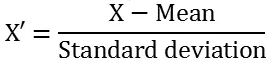

**Importante:** as médias e os desvios padrão de cada coluna devem ser calculadas somente usando os dados de treinamento. De outra forma, vamos estar vazando informação do conjunto teste.

In [52]:
# Calculo das médias e desvios padrão de cada coluna dos dados de treinamenyo
train_mean = train_df.mean()
train_std = train_df.std()

# Normalização do dados de treinamento, validação e teste
train_df = (train_df - train_mean) / train_std
val_df = (val_df - train_mean) / train_std
test_df = (test_df - train_mean) / train_std

Vamos visualizar a distribuição dos dados de cada coluna do DataFrame fazendo um gráfico que mostra as variações em torno dos seus valores médios, que no caso após normalização são todos **aproximadamente** iguais a 0.

<ipython-input-53-da0bb234bbcf>:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ = ax.set_xticklabels(df.keys(), rotation=90)


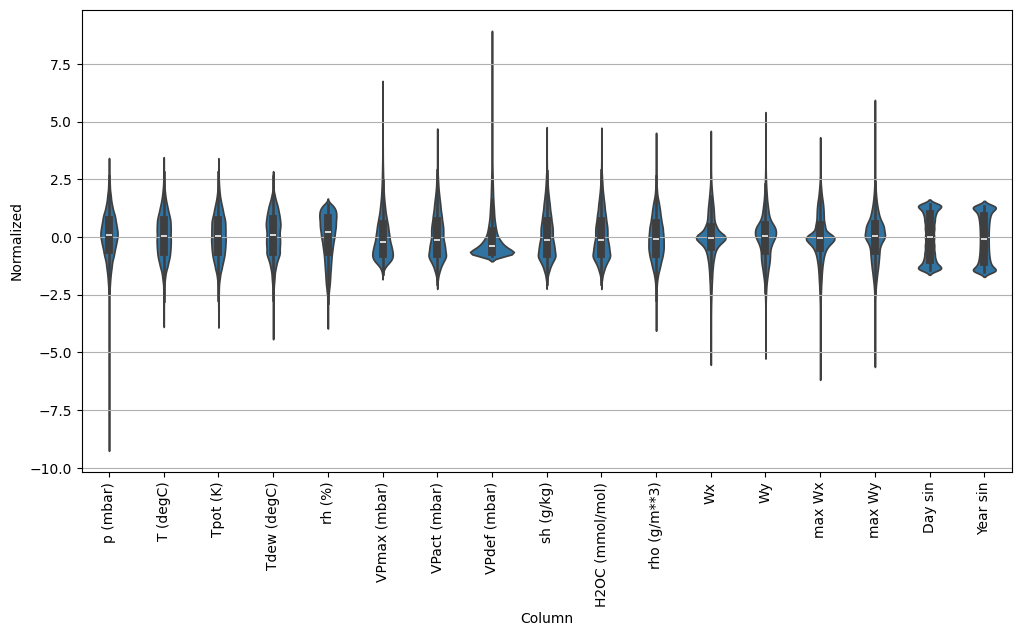

In [53]:
# Calcula desvio padrão de todas as colunas do DataFrame usando as médias calculadas anteriormente
df_dist = (df - train_mean) / train_std

# Referência Dataframe pelas distribuições
df_dist = df_dist.melt(var_name='Column', value_name='Normalized')

# Mostra gráficos das distribuições das colunas em torno das suas médias
plt.figure(figsize=(12, 6))
plt.grid()
ax = sns.violinplot(x='Column', y='Normalized', data=df_dist)
_ = ax.set_xticklabels(df.keys(), rotation=90)

## Janelamento dos dados

Vamos utilizar as funções vistas na anterior para criar janelas e dataset para configurar os exemplos de treinamento.

### Criação do dataset

Na célula abaixo é criada a função `make_window_dataset`, que recebe como entrada um DataFrame com os dados (`df`), o comprimento total da janela (`window_size`), o deslocamento de tempo entre as janelas (`shift`) e o passo de amostragem (`stride`).

Os parâmetros dessa função são os seguintes:

- `window_size`: tamanho total da janela
- `shift`: deslocamento entre janelas
- `stride`: deslocamento temporal entre amostras

Lembre que essa função não separa as entradas das saídas. Isso deve ser realizado posteriormento e o parâmetro `window_size` representa o tamanho total da janela.

In [54]:
# Função para criar lotes de janelas de uma série temporal
def make_window_dataset(df, window_size=5, shift=1, stride=1):
    ds = tf.data.Dataset.from_tensor_slices(df)
    windows = ds.window(window_size, shift=shift, stride=stride)

    def sub_to_batch(sub):
        return sub.batch(window_size, drop_remainder=True)

    windows = windows.flat_map(sub_to_batch)
    return windows

### Função para criar Datasets

Para converter os DataFrames de treinamento, validação e teste em estruturas `tf.data.Dataset` vamos usar a função (`make_dataset`), que por sua vez usa as funções `make_window_dataset` e `sep_labels`.

Esses datasets retornam pares (`janela_de_entrada`, `janela_de_saída`).

In [55]:
# Define função para criar dataset
def make_dataset(data, total_length, feature_length, label_length, label_column, shift, batch_size, stride=1):
    # Transforma dados em tensor numpy
    data = np.array(data, dtype=np.float32)

    # Cria exemplos de treinamento que contém as entradas e as saídas
    ds = make_window_dataset(data, window_size=total_length, shift=shift)

    # Define função para separar entradas das saídas
    def sep_labels(ds):
        saida = ds[-label_length:, label_column]
        saida = saida[:, tf.newaxis]
        entrada = ds[:feature_length]
        return entrada, saida

    # Divide janels em dados de entrada e saída
    ds = ds.map(sep_labels)

    # Define tamanho do lote
    ds = ds.batch(batch_size, drop_remainder=True)

    return ds

### Importante:

Tanto a entrada como a saída de um exemplo de treinamento de uma série temporal devem possuir 3 eixos:  
- 1o eixo: eixo dos exemplos (batch);
- 2a eixo: eixo do tempo;
- 3a eixo: eixo das features;

### Gráfico das janelas

Vamos usar a função (`plot`) para facilitar fazer gráficos dos dados de uma janela.

Essa função recebe como argumentos o seguinte:

- `model`: modelo usado na previsão;
- `plot_col`: índice da colun aque se deseja fazer o gráfico;
- `num_subplots`: número de gráficos de janelas desejados;

Além desses argumentos a função `plot` utiliza os parâmetros que definem a janela (`feature_length`, `offset`, `label_length`).

In [56]:
# Função para fazer gráfico dos dados de janelas
def plot(ds, model=None, plot_col=1, num_subplots=3):

    # Gera exemlos de entrada e saída
    inputs, labels = next(iter(ds.take(1)))

    # Verifica numero de gráficos a serem feitos
    max_n = min(num_subplots, len(inputs))

    for n in range(max_n):
        # Tamanho total da janela
        total_window_size = feature_length + offset

        # Cria indíces para os dados de entrada das janelas
        input_indices = np.arange(feature_length)

        # Define índice inicial das saídas nas janelas
        label_start = total_window_size - label_length

        # Define índices dos dados de saída nas janelas
        label_indices = np.arange(label_start, total_window_size)

        plt.figure(figsize=(15, 3*max_n))
        plt.subplot(max_n, 1, n+1)
        plt.ylabel('Valores')
        plt.plot(input_indices, inputs[n,:,plot_col], label='Entradas', marker='.', zorder=-10)

        if label_length==1:
            plt.scatter(label_indices, labels[n], edgecolors='k', label='Saídas reais', c='#2ca02c', s=64)
        else:
            plt.scatter(label_indices, labels[n], edgecolors='k', label='Saídas reais', c='#2ca02c', s=64)

        if model is not None:
            predictions = model(inputs)
            plt.scatter(label_indices, predictions[n, :],
                        marker='X', edgecolors='k', label='Previsões',
                        c='#ff7f0e', s=64)

        if n == 0:
            plt.legend()

        plt.xlabel('Tempo (horas)')
        plt.grid()
        plt.show()

## Modelos que usam mútiplos intervalos de tempo

Vamos utilizar modelos que fazem previsões baseados em múltiplos intervalos de tempo.

Na figura abaixo, é mostrado um esquema do funcionamento de um modelo que utiliza dados de 3 intervalos de tempo para realizar a previsão para o próximo instante de tempo.

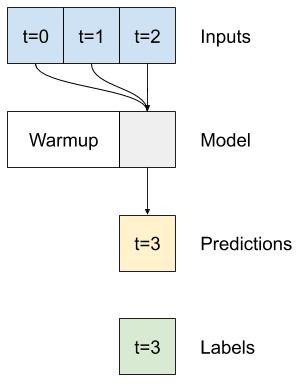

### Criar dataset

Vamos criar um dataset que pega dados de 100 intervalos de tempo e retorna a saída desejada para a próxima hora.

Na célula abaixo são criados os dataset `conv_window` de treinamento, validação e teste que retornam as 17 features em 100 intervalos de tempo consecutivos (entradas) e a temperatura desejada no próximo instante de tempo (saída desejada).

In [57]:
# Define tamanho da janela (m) e numero de previsões no futuro (h)
feature_length = 100 # número de intervalos de tempo das entradas
label_length = 1 # Número de intervalos de tempo das previsões
offset = 1 # deslocamento de tempo entre a primeira saída e o último instante das entradas

# Deslocamento temporal entre as janelas
shift = 1

# Índice da coluna com os dados de saída
label_column = 1

# Deve-se inicialmente criar janelas com a quantidade de amostras iguais ao m+L
total_length = feature_length + offset

# Cria data set de treinamento
train_conv_window = make_dataset(train_df, total_length, feature_length, label_length, label_column,
                                 shift, batch_size=32)

# Cria data set de validação
val_conv_window = make_dataset(val_df, total_length, feature_length, label_length, label_column,
                               shift, batch_size=32)

# Cria data set de teste
test_conv_window = make_dataset(test_df, total_length, feature_length, label_length, label_column,
                                     shift, batch_size=32)

# Mostra informações de um elemento do dataset de treinamento
train_conv_window.element_spec

(TensorSpec(shape=(32, 100, 17), dtype=tf.float32, name=None),
 TensorSpec(shape=(32, 1, 1), dtype=tf.float32, name=None))

Os dados de entrada de cada exemplo consiste de 100 vetores, sendo cada um com 19 features.

Podemos iterar no dataset para obter exemplos de dados.

In [ ]:
for example_inputs, example_labels in train_conv_window.take(1):
    print(f'Dimensão das entradas (batch, time, features): {example_inputs.shape}')
    print(f'Dimensão das saídas (batch, time, features): {example_labels.shape}')
    print('Entradas do 1o exemplo:', example_inputs[0].numpy())
    print('Saída do 1o exemplo:', example_labels[0].numpy())

Dimensão das entradas (batch, time, features): (32, 100, 17)
Dimensão das saídas (batch, time, features): (32, 1, 1)
Entradas do 1o exemplo: [[ 0.9453076  -1.9824733  -2.0418885  ...  0.21792787  0.36611056
  -0.06105236]
 [ 0.95976985 -2.078372   -2.1381664  ...  0.22779849  0.70719975
  -0.06002935]
 [ 0.98628396 -2.0702844  -2.1324356  ...  0.3240784   1.0000997
  -0.05900635]
 ...
 [-0.46235114 -1.237235   -1.1971647  ... -1.3864849   0.70719975
   0.03806533]
 [-0.42860588 -1.2256808  -1.1879954  ... -1.7402307   1.0000997
   0.03908513]
 [-0.38401395 -1.2557214  -1.2212342  ... -2.0703726   1.2248496
   0.04010487]]
Saída do 1o exemplo: [[-1.256877]]


Vamos fazer os gráficos de 3 exemplos de dados.

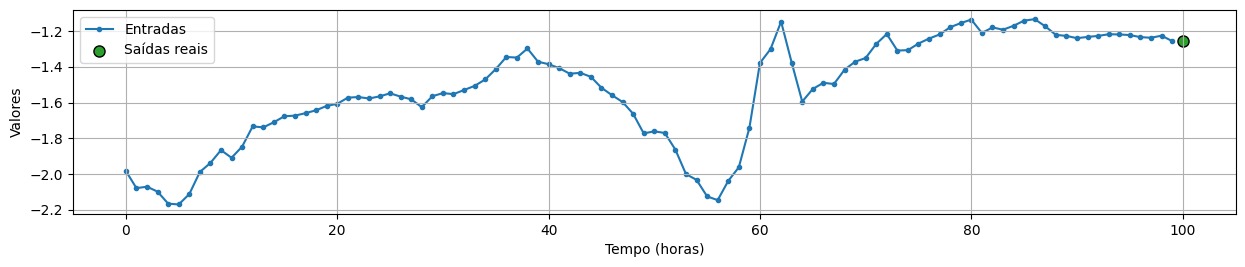

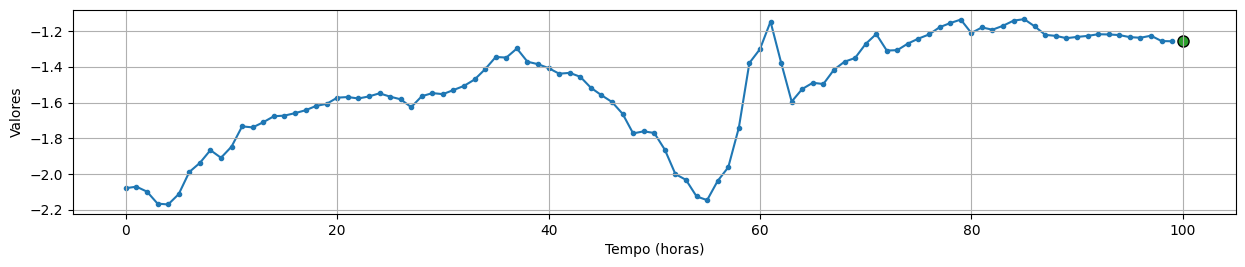

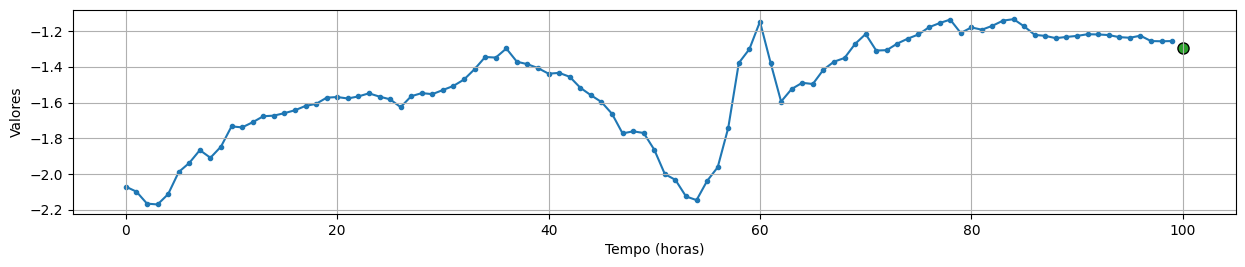

In [ ]:
plot(train_conv_window, plot_col=1)

**Obs.:** existem 17 features nos dados de entrada, mas fizemos somente os gráficos das temperaturas.

### Modelo base

Como baseline, vamos utilizar um modelo que prevê para o instante *t* o valor observado para a variável no instante *t-1*.

In [ ]:
model_base = tf.keras.Sequential([
    # Pegar o último time step (-1) e então selecionar as colunas 0, 1 e 2
    tf.keras.layers.Lambda(lambda x: x[:, -1, :]),  # Pegue o último timestep
    tf.keras.layers.Lambda(lambda x: tf.gather(x, indices=[1], axis=1)),  # Agora selecione a coluna temperatura (col. 1)
    # Adicionando uma dimensão extra para compatibilidade com a saída esperada
    tf.keras.layers.Reshape((1, 1))
])

Vamos verificar a dimensão das saídas da rede para um exemplos de dados.

In [ ]:
# Verificação da dimensão das saídas
for example_inputs, example_labels in train_conv_window.take(1):
    print('Dimensão das entradas dos exemplos:', example_inputs.shape)
    print('Dimensão das saídas dos exemplos:', example_labels.shape)

print('Dimensão das saídas da rede base:', model_base(example_inputs).shape)

Dimensão das entradas dos exemplos: (32, 100, 17)
Dimensão das saídas dos exemplos: (32, 1, 1)
Dimensão das saídas da rede base: (32, 1, 1)


In [ ]:
# Compilação do modelo
model_base.compile(loss=tf.losses.MeanSquaredError(), metrics=[tf.metrics.MeanAbsoluteError()])

Avaliação do modelo:

In [ ]:
# Cria dicionário com desempenho dos vários modelos para comparação posterior
val_performance = {}
test_performance = {}

# Avaliação da rede
val_performance['Base'] = model_base.evaluate(val_conv_window)
test_performance['Base'] = model_base.evaluate(test_conv_window)
print('Desempenho validação:', val_performance['Base'])
print('Desempenho teste:', test_performance['Base'])

325/325 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0127 - mean_absolute_error: 0.0773


/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


325/325 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0116 - mean_absolute_error: 0.0756
Desempenho validação: [0.01425765547901392, 0.08325636386871338]
Desempenho teste: [0.012340771965682507, 0.0783420279622078]


Na célula abaixo são calculadas as previsões do modelo base para 3 exemplos do conjunto de teste e apresentados os gráficos.

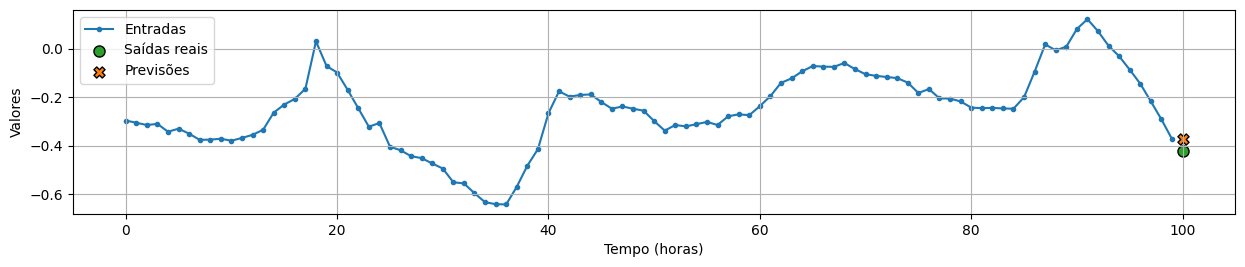

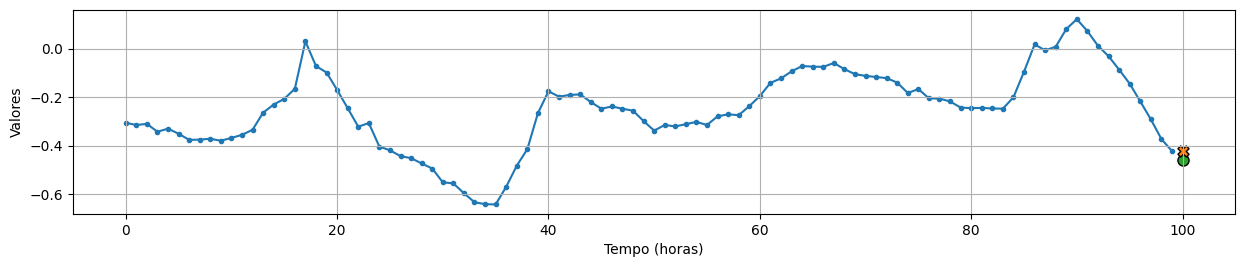

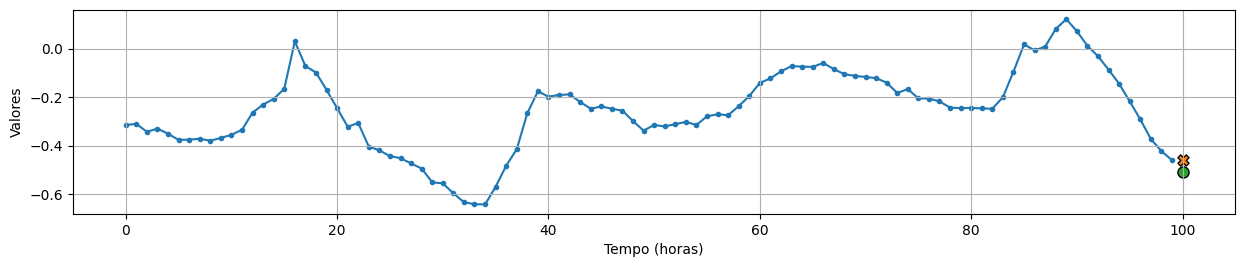

In [ ]:
# Calcula previsões e mostra gráfico
plot(test_conv_window, model=model_base)

### Rede neural convolucional

A primeira rede neural que utilizaremos de comparação é uma rede convolucional. Vamos deixar a rede densa de lado, já que ela obteve resultados ruins nos testes realizados na aula passada.

Como vamos treinar muitos modelos, vamos usar a função `compile_and_fit` para compilar e treinar os modelos. Essa é a mesma função usada na aula anterior, sendo que recebe como argumentos:

- Modelo;
- Dataset com dados de treinamento;
- Dataset com dados de validação.

O otimizador, função de custo e métrica utlizados são os seguintes:

- Otimizador Adam;
- Função de custo MSE;
- Métrica MAE.

In [ ]:
MAX_EPOCHS = 20

# Função para compilar e treinar um modelo
def compile_and_fit(model, train_ds, val_ds):
    # Compilação do modelo
    model.compile(loss=tf.losses.MeanSquaredError(),
                  optimizer=tf.optimizers.Adam(),
                  metrics=[tf.metrics.MeanAbsoluteError()])

    # Apresenta sumario da rede
    model.summary()
    print(' ')

    # Treinamento do modelo
    history = model.fit(train_ds, epochs=MAX_EPOCHS, validation_data=val_ds)

    return history

Na célula abaixo é configurada uma rede com a primeira camada convolucional 1D seguida de duas camadas densas. Oberva-se que a única diferença dessa rede para a rede densa anterior é que a primeira camada é convolucional.


In [ ]:
# Define comprimento do filtro 1D
filter_size = 3

# Instancia modelo sequencial
conv_model = tf.keras.Sequential()

# Primeira camada convolucional
conv_model.add(tf.keras.layers.Conv1D(filters=32, kernel_size=filter_size, activation='relu', input_shape=(100, 17), padding='same'))
conv_model.add(tf.keras.layers.MaxPooling1D(pool_size=2))

# Segunda camada convolucional
conv_model.add(tf.keras.layers.Conv1D(filters=64, kernel_size=filter_size, activation='relu', padding='same'))
conv_model.add(tf.keras.layers.MaxPooling1D(pool_size=2))

# Terceira camada convolucional
conv_model.add(tf.keras.layers.Conv1D(filters=128, kernel_size=filter_size, activation='relu', padding='same'))
conv_model.add(tf.keras.layers.MaxPooling1D(pool_size=2))

# Camada de achatamento para transformar os dados para uma dimensão
conv_model.add(tf.keras.layers.Flatten())

# Camada densa
conv_model.add(tf.keras.layers.Dense(units=128, activation='relu'))

# Camada de saída
conv_model.add(tf.keras.layers.Dense(units=1))

# Apresenta modelo
conv_model.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 100, 32)             │           1,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 50, 32)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 50, 64)              │           6,208 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 25, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_2 (Conv1D)                    │ (None, 25, 128)             │          24,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_2 (MaxPooling1D)       │ (None, 12, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1536)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         196,736 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 229,441 (896.25 KB)

 Trainable params: 229,441 (896.25 KB)

 Non-trainable params: 0 (0.00 B)

Obs.: Não é necessária a camada de Flatten para transformar as entradas em vetores. A camada convolucional 1D processa múltiplos instantes de tempo de uma única vez.

- Nota-se que a dimensão dos dados de entrada da rede foi definida como sendo `(None, 19)`. Isso é feito para que a rede aceite uma sequencia de entradas com qualquer comprimento.

- A dimensão do filtro é definida como sendo igual a 100 para que sejam processados 100 intervalos de tempo de dados de entrada para calcular cada previsão.

Vamos executar a rede convolucional para verificar a dimensão das saídas da rede para um exemplo.

In [ ]:
for example_inputs, example_labels in train_conv_window.take(1):
    print('Dimensão das entradas dos exemplos:', example_inputs.shape)
    print('Dimensão das saídas dos exemplos:', example_labels.shape)

print('Dimensão das saídas da rede:', conv_model(example_inputs).shape)

Dimensão das entradas dos exemplos: (32, 100, 17)
Dimensão das saídas dos exemplos: (32, 1, 1)
Dimensão das saídas da rede: (32, 1)


Compilação e trenamento da rede.

In [ ]:
# Compilação e treinamento da rede
history = compile_and_fit(conv_model, train_conv_window, test_conv_window)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 100, 32)             │           1,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 50, 32)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 50, 64)              │           6,208 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 25, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_2 (Conv1D)                    │ (None, 25, 128)             │          24,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_2 (MaxPooling1D)       │ (None, 12, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1536)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         196,736 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 229,441 (896.25 KB)

 Trainable params: 229,441 (896.25 KB)

 Non-trainable params: 0 (0.00 B)

 
Epoch 1/20
1530/1530 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - loss: 0.2601 - mean_absolute_error: 0.3675 - val_loss: 0.0891 - val_mean_absolute_error: 0.2194
Epoch 2/20
1530/1530 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - loss: 0.0694 - mean_absolute_error: 0.1840 - val_loss: 0.0427 - val_mean_absolute_error: 0.1524
Epoch 3/20
1530/1530 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 0.0266 - mean_absolute_error: 0.1185 - val_loss: 0.0145 - val_mean_absolute_error: 0.0924
Epoch 4/20
1530/1530 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - loss: 0.0170 - mean_absolute_error: 0.0961 - val_loss: 0.0137 - val_mean_absolute_error: 0.0884
Epoch 5/20
1530/1530 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - loss: 0.0140 - mean_absolute_error: 0.0874 - val_loss: 0.0113 - val_mean_absolute_error: 0.0809
Epoch 6/20
1530/1530 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 0.0117 - mean_absolute_error: 0.0807 - val_loss: 0.0118 - val_mean_absolute_error: 0.0822
Epoch 7/20
1530/1530 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - loss: 0.0145 - m

Avaliação do modelo:

In [ ]:
# Avaliação da rede
val_performance['Conv'] = conv_model.evaluate(val_conv_window)
test_performance['Conv'] = conv_model.evaluate(test_conv_window)
print('\nDesempenho validação:', val_performance['Conv'])
print('Desempenho teste:', test_performance['Conv'])

325/325 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0088 - mean_absolute_error: 0.0669
325/325 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0096 - mean_absolute_error: 0.0739

Desempenho validação: [0.010663521476089954, 0.07468956708908081]
Desempenho teste: [0.009245764464139938, 0.07192470878362656]


Na célula abaixo são calculas as previsões do modelo `conv_model` para 3 exemplos do conjunto de teste e apresentados os gráficos.

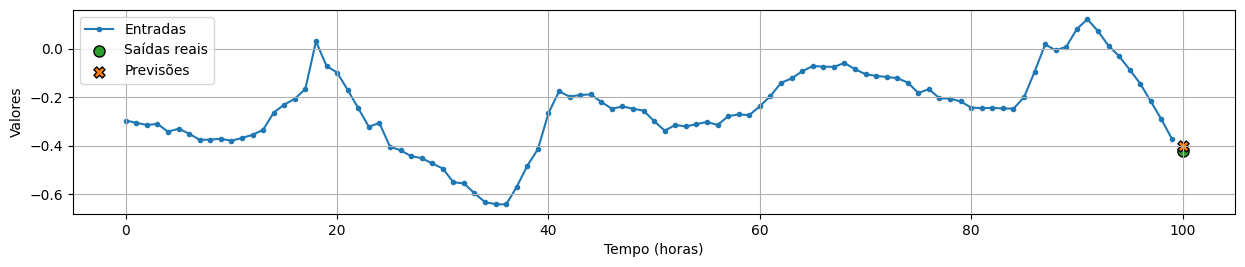

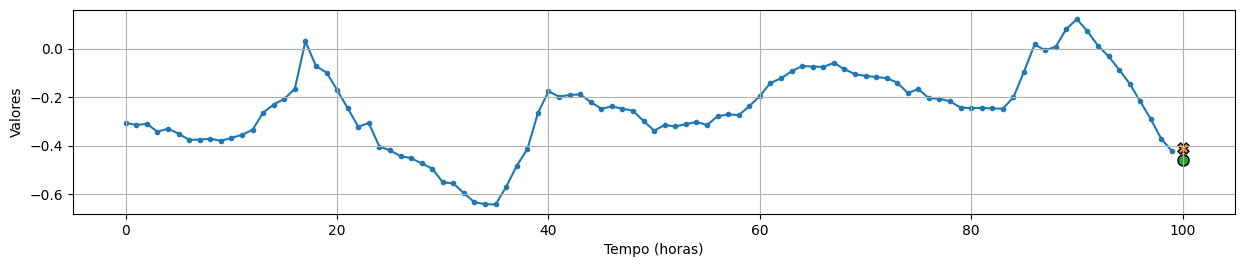

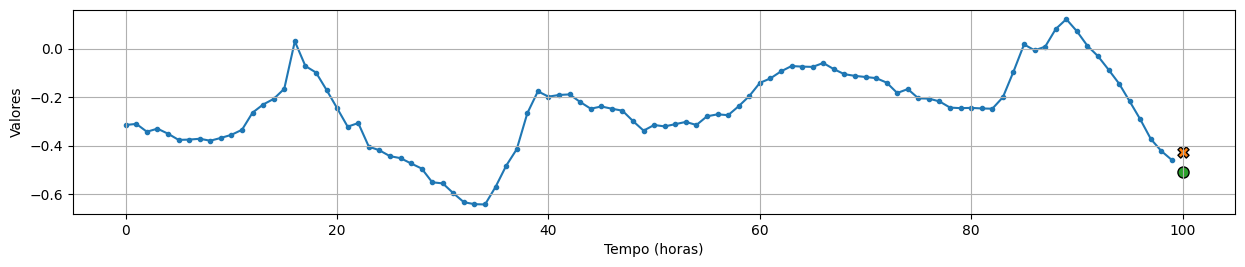

In [ ]:
# Calcula previsões e mostra gráfico
plot(test_conv_window, model=conv_model)

### Comparação dos modelos

Vamos fazer um gráfico das métricas dos dois modelos que temos até agora, o `based_model` e `conv_model`, para comparar os seus desempenhos.

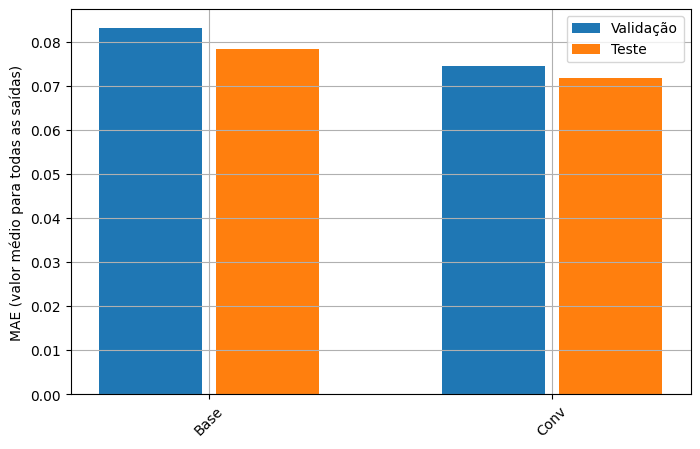

In [ ]:
x = np.arange(len(val_performance))
width = 0.3

val_mae = []
for v in val_performance.values():
    val_mae.append(v[1])
val_mae = np.array(val_mae)

test_mae = []
for v in test_performance.values():
    test_mae.append(v[1])
test_mae = np.array(test_mae)

plt.figure(figsize=(8,5))
plt.bar(x - 0.17, val_mae, width, label='Validação')
plt.bar(x + 0.17, test_mae, width, label='Teste')
plt.xticks(ticks=x, labels=val_performance.keys(),
           rotation=45)
plt.ylabel('MAE (valor médio para todas as saídas)')
_ = plt.legend()
plt.grid()

In [ ]:
for name, value in test_performance.items():
    print(f'{name:15s}: {value[1]:0.4f}')

Base           : 0.0783
Conv           : 0.0719


Vamos calcular o erro médio percentual em relação aos valores não normalizados das saídas.

<ipython-input-39-b17a99081b01>:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  val_MAP = 100*(val_mae*train_std[1]/train_mean[1])
<ipython-input-39-b17a99081b01>:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  test_MAP = 100*(test_mae*train_std[1]/train_mean[1])


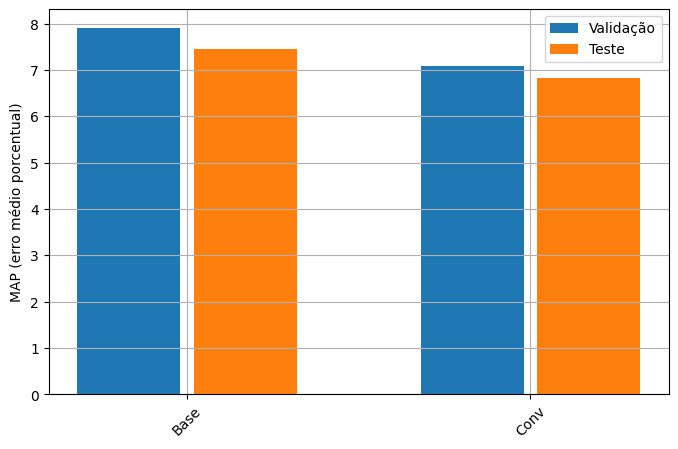

Base        : 7.4443 %
Convolucional: 6.8345 %


In [ ]:
# Transforma erros de previsão normalizados em não normalizados
val_MAP = 100*(val_mae*train_std[1]/train_mean[1])
test_MAP = 100*(test_mae*train_std[1]/train_mean[1])

plt.figure(figsize=(8,5))
plt.bar(x - 0.17, val_MAP, width, label='Validação')
plt.bar(x + 0.17, test_MAP, width, label='Teste')
plt.xticks(ticks=x, labels=val_performance.keys(),
           rotation=45)
plt.ylabel('MAP (erro médio porcentual)')
_ = plt.legend()
plt.grid()
plt.show()

print('Base        :', f'{test_MAP[0]:0.4f} %')
print('Convolucional:', f'{test_MAP[1]:0.4f} %')

A rede convolucional obteve um erro médio consideravelmente menor que o modelo base.

### Rede recorrente

Vamos agora construir uma rede recorrente simples, com apenas uma camada. Vimos que ela obteve um desempenho semelhante à rede com várias camadas, sendo mais rápida de treinar.

In [ ]:
# Instancia rede sequencial
vanilla_rnn = tf.keras.Sequential()

# Adiciona uma camada recorrente. Assume-se que o input_shape seja (tempo, características)
vanilla_rnn.add(tf.keras.layers.SimpleRNN(units=32, activation='relu', input_shape=(100, 17)))

# Inclui uma camada densa para transformar a saída do RNN para a saída desejada
vanilla_rnn.add(tf.keras.layers.Dense(units=1))

# Redimensiona saída para redefinir o eixo do tempo. Shape: (saídas) => (1, saídas)
vanilla_rnn.add(tf.keras.layers.Reshape([1, -1]))

# Resumo da rede
vanilla_rnn.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 32)                  │           1,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape_1 (Reshape)                  │ (None, 1, 1)                │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,633 (6.38 KB)

 Trainable params: 1,633 (6.38 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
for example_inputs, example_labels in train_conv_window.take(1):
    print('Dimensão das entradas dos exemplos:', example_inputs.shape)
    print('Dimensão das saídas dos exemplos:', example_labels.shape)

print('Dimensão das saídas da rede:', vanilla_rnn(example_inputs).shape)

Dimensão das entradas dos exemplos: (32, 100, 17)
Dimensão das saídas dos exemplos: (32, 1, 1)
Dimensão das saídas da rede: (32, 1, 1)


Compilação e trenamento da rede.

In [ ]:
# Compilação e treinamento da rede
history = compile_and_fit(vanilla_rnn, train_conv_window, test_conv_window)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 32)                  │           1,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape_1 (Reshape)                  │ (None, 1, 1)                │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,633 (6.38 KB)

 Trainable params: 1,633 (6.38 KB)

 Non-trainable params: 0 (0.00 B)

 
Epoch 1/20
   1528/Unknown 27s 16ms/step - loss: 0.6570 - mean_absolute_error: 0.3958

/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


1530/1530 ━━━━━━━━━━━━━━━━━━━━ 32s 20ms/step - loss: 0.6560 - mean_absolute_error: 0.3954 - val_loss: 0.0239 - val_mean_absolute_error: 0.1188
Epoch 2/20
1530/1530 ━━━━━━━━━━━━━━━━━━━━ 40s 20ms/step - loss: 0.0237 - mean_absolute_error: 0.1133 - val_loss: 0.0152 - val_mean_absolute_error: 0.0958
Epoch 3/20
1530/1530 ━━━━━━━━━━━━━━━━━━━━ 28s 19ms/step - loss: 0.0168 - mean_absolute_error: 0.0935 - val_loss: 0.0098 - val_mean_absolute_error: 0.0744
Epoch 4/20
1530/1530 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - loss: 0.0120 - mean_absolute_error: 0.0789 - val_loss: 0.0092 - val_mean_absolute_error: 0.0723
Epoch 5/20
1530/1530 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - loss: 0.0103 - mean_absolute_error: 0.0735 - val_loss: 0.0091 - val_mean_absolute_error: 0.0720
Epoch 6/20
1530/1530 ━━━━━━━━━━━━━━━━━━━━ 42s 21ms/step - loss: 0.0093 - mean_absolute_error: 0.0700 - val_loss: 0.0089 - val_mean_absolute_error: 0.0706
Epoch 7/20
1530/1530 ━━━━━━━━━━━━━━━━━━━━ 30s 20ms/step - loss: 0.0089 - mean_absolute_

Avaliação do modelo:

In [ ]:
# Avaliação da rede
val_performance['VanillaRNN'] = vanilla_rnn.evaluate(val_conv_window)
test_performance['VanillaRNN'] = vanilla_rnn.evaluate(test_conv_window)
print('\nDesempenho validação:', val_performance['VanillaRNN'])
print('Desempenho teste:', test_performance['VanillaRNN'])

325/325 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0081 - mean_absolute_error: 0.0661
325/325 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0080 - mean_absolute_error: 0.0652

Desempenho validação: [0.008898777887225151, 0.06900974363088608]
Desempenho teste: [0.007704196497797966, 0.06481810659170151]


Na célula abaixo são calculas as previsões do modelo `vanilla_rnn` para 3 exemplos do conjunto de teste e apresentados os gráficos.

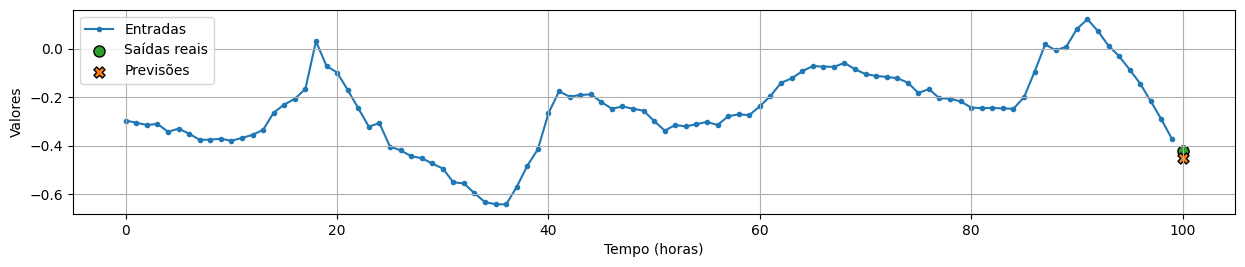

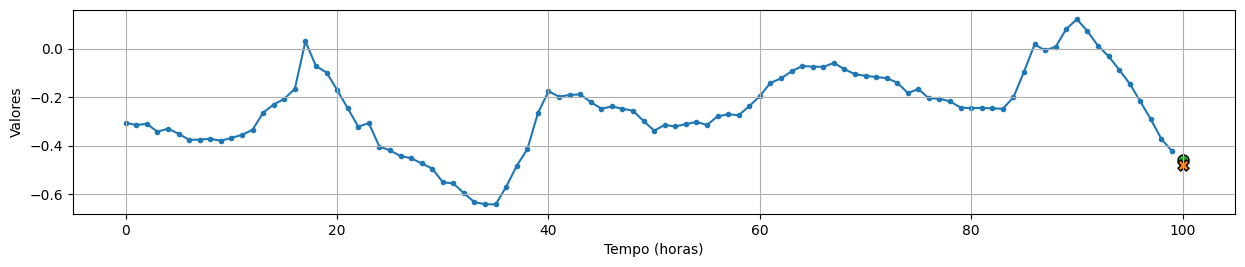

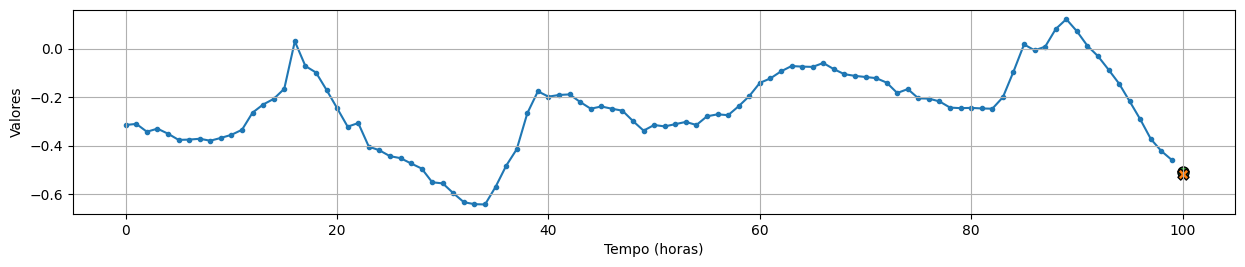

In [ ]:
# Calcula previsões e mostra gráfico
plot(test_conv_window, model=vanilla_rnn)

#### Comparação dos modelos

Vamos fazer um gráfico das métricas dos modelos `based_model`, `conv_model` e `vanilla_rnn` para comparar os seus desempenhos.

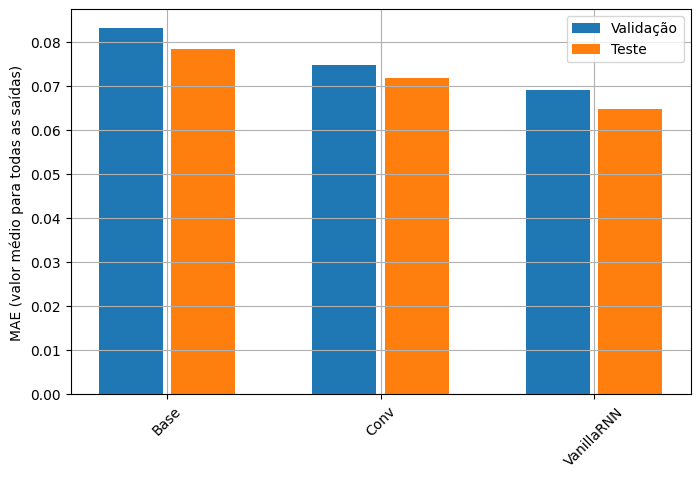

In [ ]:
x = np.arange(len(val_performance))
width = 0.3

val_mae = []
for v in val_performance.values():
    val_mae.append(v[1])
val_mae = np.array(val_mae)

test_mae = []
for v in test_performance.values():
    test_mae.append(v[1])
test_mae = np.array(test_mae)

plt.figure(figsize=(8,5))
plt.bar(x - 0.17, val_mae, width, label='Validação')
plt.bar(x + 0.17, test_mae, width, label='Teste')
plt.xticks(ticks=x, labels=val_performance.keys(),
           rotation=45)
plt.ylabel('MAE (valor médio para todas as saídas)')
_ = plt.legend()
plt.grid()

In [ ]:
for name, value in test_performance.items():
    print(f'{name:15s}: {value[1]:0.4f}')

Base           : 0.0783
Conv           : 0.0719
VanillaRNN     : 0.0648


Vamos calcular o erro médio percentual em relação aos valores não normalizados das saídas.

<ipython-input-47-b4786cc8ff64>:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  val_MAP = 100*(val_mae*train_std[1]/train_mean[1])
<ipython-input-47-b4786cc8ff64>:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  test_MAP = 100*(test_mae*train_std[1]/train_mean[1])


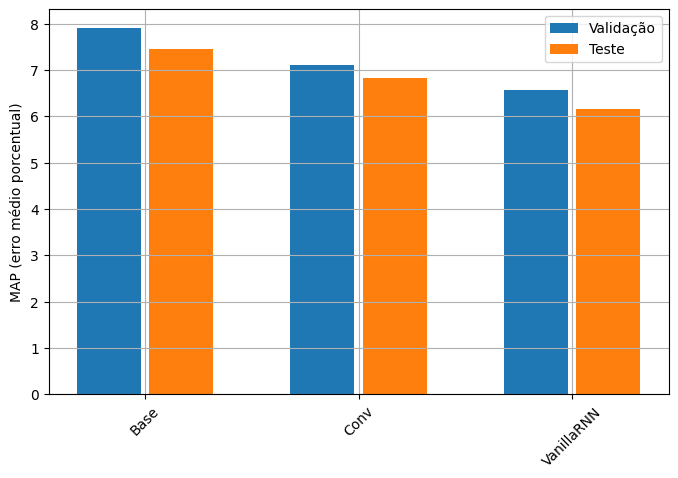

Base        : 7.4443 %
Convolucional: 6.8345 %
RNN Vanilla: 6.1593 %


In [ ]:
# Transforma erros de previsão normalizados em não normalizados
val_MAP = 100*(val_mae*train_std[1]/train_mean[1])
test_MAP = 100*(test_mae*train_std[1]/train_mean[1])

plt.figure(figsize=(8,5))
plt.bar(x - 0.17, val_MAP, width, label='Validação')
plt.bar(x + 0.17, test_MAP, width, label='Teste')
plt.xticks(ticks=x, labels=val_performance.keys(),
           rotation=45)
plt.ylabel('MAP (erro médio porcentual)')
_ = plt.legend()
plt.grid()
plt.show()

print('Base        :', f'{test_MAP[0]:0.4f} %')
print('Convolucional:', f'{test_MAP[1]:0.4f} %')
print('RNN Vanilla:', f'{test_MAP[2]:0.4f} %')

A rede recorrente simples (vanilla) obteve o melhor desempenho entre os três modelos testados.

Agora, vamos testar dois modelos com portas: LSTM e GRU.

### LSTM

O primeiro modelo com porta que treinaremos é uma rede LSTM com uma única camada.

In [ ]:
# Instancia uma rede sequencial
lstm_rnn = tf.keras.Sequential()

# Adiciona uma camada LSTM. Assume-se que o input_shape seja (tempo, características)
lstm_rnn.add(tf.keras.layers.LSTM(units=32, activation='relu', input_shape=(100, 17)))

# Inclui uma camada densa para transformar a saída do LSTM para a saída desejada
lstm_rnn.add(tf.keras.layers.Dense(units=1))

# Redimensiona saída para redefinir o eixo do tempo. Shape: (saídas) => (1, saídas)
lstm_rnn.add(tf.keras.layers.Reshape([1, -1]))

# Resumo da rede
lstm_rnn.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                        │ (None, 32)                  │           6,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              33 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape_4 (Reshape)                  │ (None, 1, 1)                │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,433 (25.13 KB)

 Trainable params: 6,433 (25.13 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
for example_inputs, example_labels in train_conv_window.take(1):
    print('Dimensão das entradas dos exemplos:', example_inputs.shape)
    print('Dimensão das saídas dos exemplos:', example_labels.shape)

print('Dimensão das saídas da rede:', lstm_rnn(example_inputs).shape)

Dimensão das entradas dos exemplos: (32, 100, 17)
Dimensão das saídas dos exemplos: (32, 1, 1)
Dimensão das saídas da rede: (32, 1, 1)


Compilação e trenamento da rede.

In [ ]:
# Compilação e treinamento da rede
history = compile_and_fit(lstm_rnn, train_conv_window, test_conv_window)

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                        │ (None, 32)                  │           6,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              33 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape_4 (Reshape)                  │ (None, 1, 1)                │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,433 (25.13 KB)

 Trainable params: 6,433 (25.13 KB)

 Non-trainable params: 0 (0.00 B)

 
Epoch 1/20
1530/1530 ━━━━━━━━━━━━━━━━━━━━ 29s 18ms/step - loss: 0.1317 - mean_absolute_error: 0.2272 - val_loss: 0.0194 - val_mean_absolute_error: 0.1069
Epoch 2/20
1530/1530 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - loss: 0.0111 - mean_absolute_error: 0.0755 - val_loss: 0.0138 - val_mean_absolute_error: 0.0918
Epoch 3/20
1530/1530 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - loss: 0.0097 - mean_absolute_error: 0.0711 - val_loss: 0.0119 - val_mean_absolute_error: 0.0846
Epoch 4/20
1530/1530 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - loss: 0.0085 - mean_absolute_error: 0.0661 - val_loss: 0.0111 - val_mean_absolute_error: 0.0816
Epoch 5/20
1530/1530 ━━━━━━━━━━━━━━━━━━━━ 47s 22ms/step - loss: 0.0082 - mean_absolute_error: 0.0648 - val_loss: 0.0106 - val_mean_absolute_error: 0.0792
Epoch 6/20
1530/1530 ━━━━━━━━━━━━━━━━━━━━ 29s 19ms/step - loss: 0.0079 - mean_absolute_error: 0.0635 - val_loss: 0.0099 - val_mean_absolute_error: 0.0762
Epoch 7/20
1530/1530 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - loss: 0.0075 - m

Avaliação do modelo.

In [ ]:
# Avaliação da rede
val_performance['LSTM'] = lstm_rnn.evaluate(val_conv_window)
test_performance['LSTM'] = lstm_rnn.evaluate(test_conv_window)
print('Desempenho validação:', val_performance['LSTM'])
print('Desempenho teste:', test_performance['LSTM'])

325/325 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0079 - mean_absolute_error: 0.0646
325/325 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0081 - mean_absolute_error: 0.0679
Desempenho validação: [0.009202997200191021, 0.07038472592830658]
Desempenho teste: [0.008113125339150429, 0.0678364709019661]


Na célula abaixo são calculas as previsões do modelo `lstm_rnn` para 3 exemplos do conjunto de teste e apresentados os gráficos.

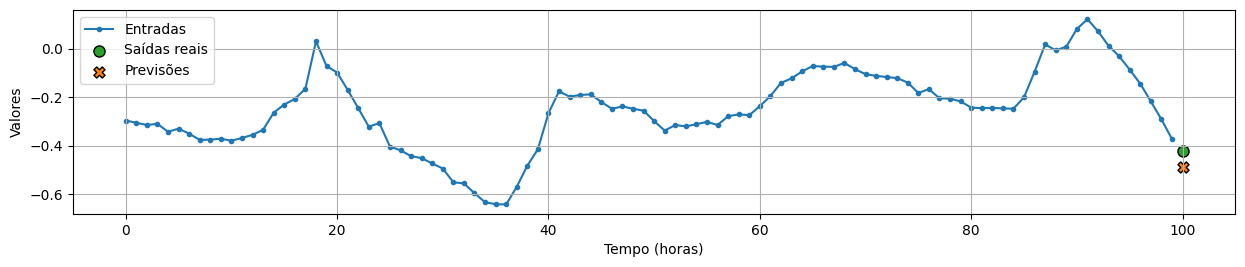

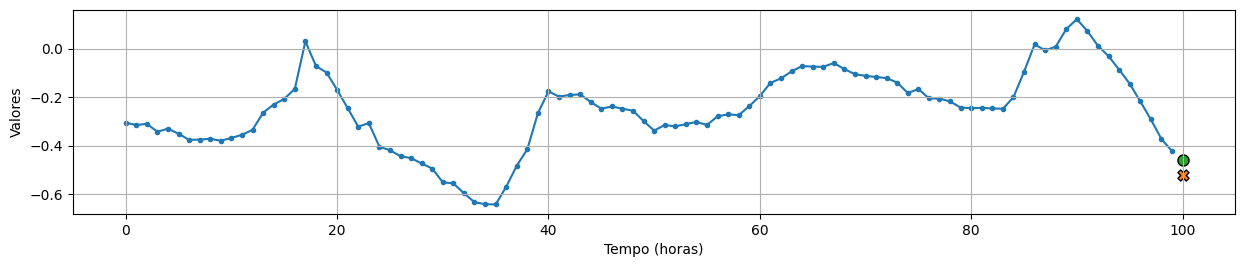

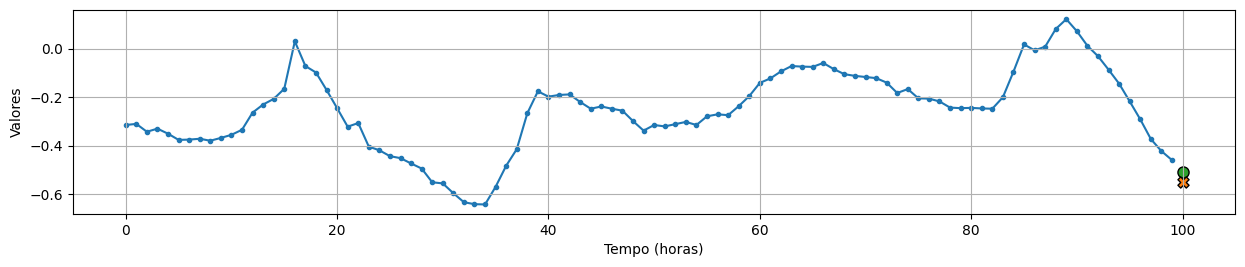

In [ ]:
# Calcula previsões e mostra gráfico
plot(test_conv_window, model=lstm_rnn)

#### Comparação dos modelos

Vamos fazer um gráfico das métricas dos modelos que vimos até aqui.

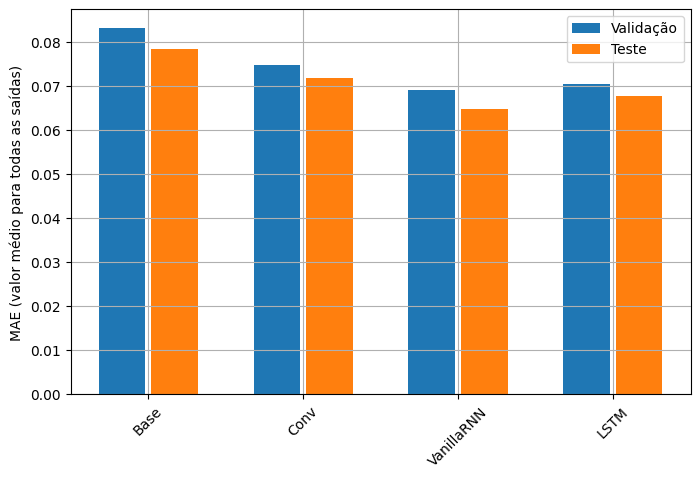

In [ ]:
x = np.arange(len(val_performance))
width = 0.3

val_mae = []
for v in val_performance.values():
    val_mae.append(v[1])
val_mae = np.array(val_mae)

test_mae = []
for v in test_performance.values():
    test_mae.append(v[1])
test_mae = np.array(test_mae)

plt.figure(figsize=(8,5))
plt.bar(x - 0.17, val_mae, width, label='Validação')
plt.bar(x + 0.17, test_mae, width, label='Teste')
plt.xticks(ticks=x, labels=val_performance.keys(),
           rotation=45)
plt.ylabel('MAE (valor médio para todas as saídas)')
_ = plt.legend()
plt.grid()

In [ ]:
for name, value in test_performance.items():
    print(f'{name:15s}: {value[1]:0.4f}')

Base           : 0.0783
Conv           : 0.0719
VanillaRNN     : 0.0648
LSTM           : 0.0678


Observa-se que o desempenho das duas redes são semelhantes.

Vamos calcular o erro médio percentual em relação aos valores não normalizados das saídas.

<ipython-input-66-b86ae4c4ac02>:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  val_MAP = 100*(val_mae*train_std[1]/train_mean[1])
<ipython-input-66-b86ae4c4ac02>:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  test_MAP = 100*(test_mae*train_std[1]/train_mean[1])


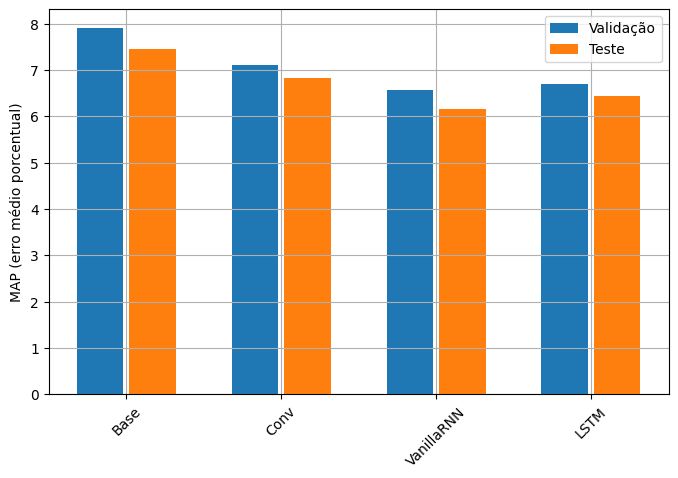

Base        : 7.4443 %
Convolucional: 6.8345 %
RNN Vanilla: 6.1593 %
LSTM: 6.4461 %


In [ ]:
# Transforma erros de previsão normalizados em não normalizados
val_MAP = 100*(val_mae*train_std[1]/train_mean[1])
test_MAP = 100*(test_mae*train_std[1]/train_mean[1])

plt.figure(figsize=(8,5))
plt.bar(x - 0.17, val_MAP, width, label='Validação')
plt.bar(x + 0.17, test_MAP, width, label='Teste')
plt.xticks(ticks=x, labels=val_performance.keys(),
           rotation=45)
plt.ylabel('MAP (erro médio porcentual)')
_ = plt.legend()
plt.grid()
plt.show()

print('Base        :', f'{test_MAP[0]:0.4f} %')
print('Convolucional:', f'{test_MAP[1]:0.4f} %')
print('RNN Vanilla:', f'{test_MAP[2]:0.4f} %')
print('LSTM:', f'{test_MAP[3]:0.4f} %')

A rede LSTM obteve um resultado ligeiramente superior à rede RNN vanilla (um resultado que provavelmente está dentro da margem de erro).

### GRU

O segundo modelo com porta que testaremos é uma rede GRU, também com uma única camada.

In [ ]:
# Instancia uma rede sequencial
gru_rnn = tf.keras.Sequential()

# Adiciona uma camada GRU. Assume-se que o input_shape seja (tempo, características)
gru_rnn.add(tf.keras.layers.GRU(units=32, activation='relu', input_shape=(100, 17)))

# Inclui uma camada densa para transformar a saída do GRU para a saída desejada
gru_rnn.add(tf.keras.layers.Dense(units=1))

# Redimensiona saída para redefinir o eixo do tempo. Shape: (saídas) => (1, saídas)
gru_rnn.add(tf.keras.layers.Reshape([1, -1]))

# Resumo da rede
gru_rnn.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru_1 (GRU)                          │ (None, 32)                  │           4,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 1)                   │              33 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape_5 (Reshape)                  │ (None, 1, 1)                │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,929 (19.25 KB)

 Trainable params: 4,929 (19.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
for example_inputs, example_labels in train_conv_window.take(1):
    print('Dimensão das entradas dos exemplos:', example_inputs.shape)
    print('Dimensão das saídas dos exemplos:', example_labels.shape)

print('Dimensão das saídas da rede:', gru_rnn(example_inputs).shape)

Dimensão das entradas dos exemplos: (32, 100, 17)
Dimensão das saídas dos exemplos: (32, 1, 1)
Dimensão das saídas da rede: (32, 1, 1)


Compilação e trenamento da rede.

In [ ]:
# Compilação e treinamento da rede
history = compile_and_fit(gru_rnn, train_conv_window, test_conv_window)

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru_1 (GRU)                          │ (None, 32)                  │           4,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 1)                   │              33 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape_5 (Reshape)                  │ (None, 1, 1)                │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,929 (19.25 KB)

 Trainable params: 4,929 (19.25 KB)

 Non-trainable params: 0 (0.00 B)

 
Epoch 1/20
   1530/Unknown 32s 20ms/step - loss: 0.1493 - mean_absolute_error: 0.1951

/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


1530/1530 ━━━━━━━━━━━━━━━━━━━━ 37s 23ms/step - loss: 0.1492 - mean_absolute_error: 0.1950 - val_loss: 0.0123 - val_mean_absolute_error: 0.0846
Epoch 2/20
1530/1530 ━━━━━━━━━━━━━━━━━━━━ 36s 24ms/step - loss: 0.0159 - mean_absolute_error: 0.0907 - val_loss: 0.0109 - val_mean_absolute_error: 0.0810
Epoch 3/20
1530/1530 ━━━━━━━━━━━━━━━━━━━━ 36s 23ms/step - loss: 0.0107 - mean_absolute_error: 0.0749 - val_loss: 0.0092 - val_mean_absolute_error: 0.0731
Epoch 4/20
1530/1530 ━━━━━━━━━━━━━━━━━━━━ 37s 24ms/step - loss: 0.0097 - mean_absolute_error: 0.0716 - val_loss: 0.0086 - val_mean_absolute_error: 0.0696
Epoch 5/20
1530/1530 ━━━━━━━━━━━━━━━━━━━━ 34s 23ms/step - loss: 0.0086 - mean_absolute_error: 0.0673 - val_loss: 0.0084 - val_mean_absolute_error: 0.0688
Epoch 6/20
1530/1530 ━━━━━━━━━━━━━━━━━━━━ 33s 22ms/step - loss: 0.0080 - mean_absolute_error: 0.0644 - val_loss: 0.0082 - val_mean_absolute_error: 0.0679
Epoch 7/20
1530/1530 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - loss: 0.0077 - mean_absolute_

Avaliação do modelo.

In [ ]:
# Avaliação da rede
val_performance['GRU'] = gru_rnn.evaluate(val_conv_window)
test_performance['GRU'] = gru_rnn.evaluate(test_conv_window)
print('Desempenho validação:', val_performance['GRU'])
print('Desempenho teste:', test_performance['GRU'])

325/325 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0075 - mean_absolute_error: 0.0639
325/325 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0070 - mean_absolute_error: 0.0617
Desempenho validação: [0.008159521967172623, 0.06586913019418716]
Desempenho teste: [0.007012687623500824, 0.06150803342461586]


Na célula abaixo são calculas as previsões do modelo `vanilla_rnn` para 3 exemplos do conjunto de teste e apresentados os gráficos.

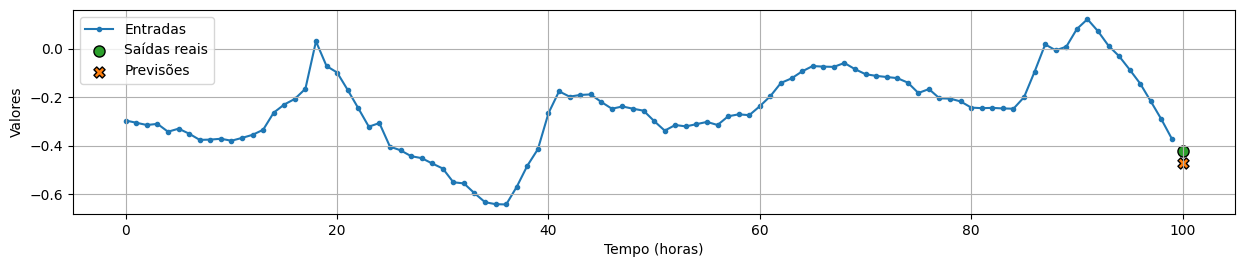

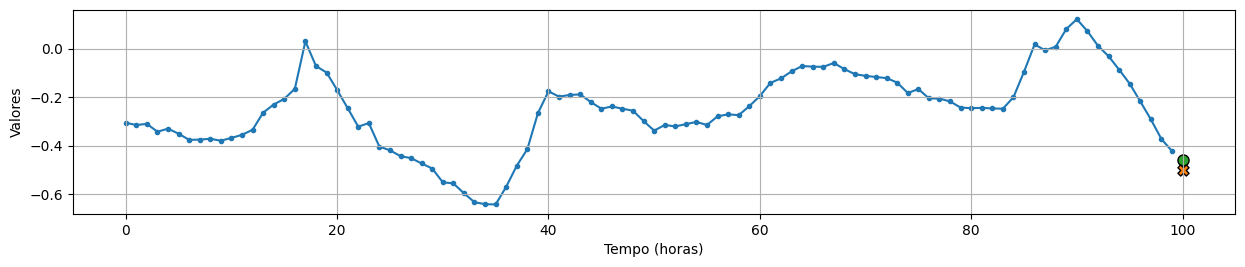

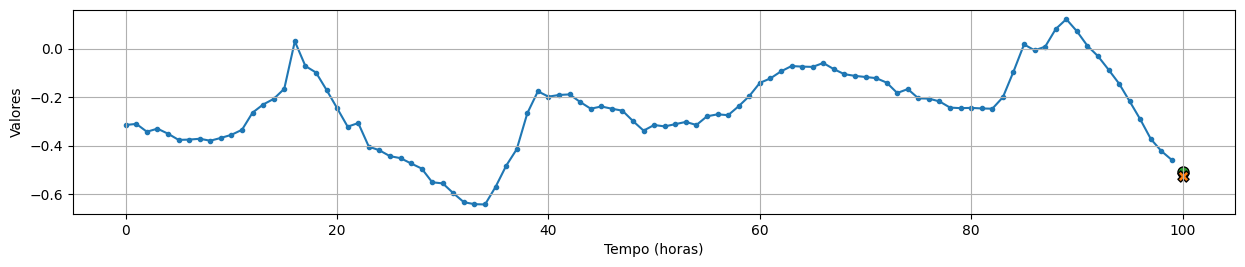

In [ ]:
# Calcula previsões e mostra gráfico
plot(test_conv_window, model=gru_rnn)

#### Comparação dos modelos

Vamos fazer um gráfico dos modelos que vimos até aqui.

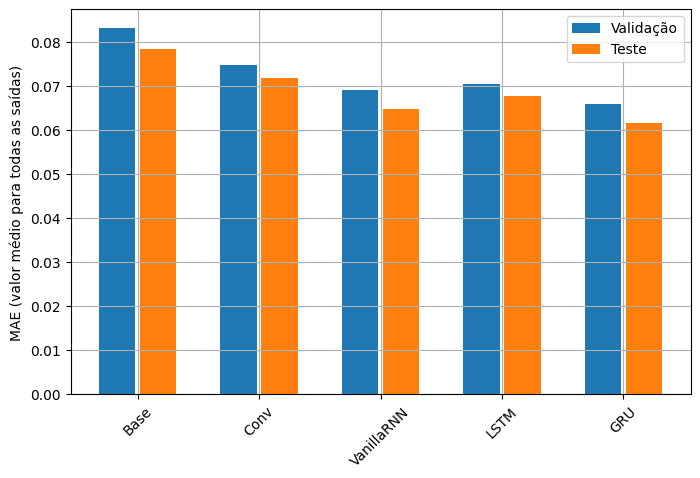

In [ ]:
x = np.arange(len(val_performance))
width = 0.3

val_mae = []
for v in val_performance.values():
    val_mae.append(v[1])
val_mae = np.array(val_mae)

test_mae = []
for v in test_performance.values():
    test_mae.append(v[1])
test_mae = np.array(test_mae)

plt.figure(figsize=(8,5))
plt.bar(x - 0.17, val_mae, width, label='Validação')
plt.bar(x + 0.17, test_mae, width, label='Teste')
plt.xticks(ticks=x, labels=val_performance.keys(),
           rotation=45)
plt.ylabel('MAE (valor médio para todas as saídas)')
_ = plt.legend()
plt.grid()

In [ ]:
for name, value in test_performance.items():
    print(f'{name:15s}: {value[1]:0.4f}')

Base           : 0.0783
Conv           : 0.0719
VanillaRNN     : 0.0648
LSTM           : 0.0678
GRU            : 0.0615


Vamos calcular o erro médio percentual em relação aos valores não normalizados das saídas.

<ipython-input-74-d235644ecf9f>:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  val_MAP = 100*(val_mae*train_std[1]/train_mean[1])
<ipython-input-74-d235644ecf9f>:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  test_MAP = 100*(test_mae*train_std[1]/train_mean[1])


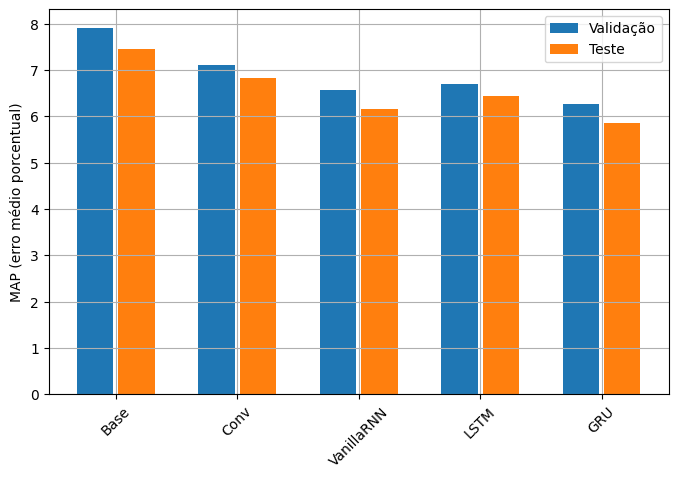

Base        : 7.4443 %
Convolucional: 6.8345 %
RNN Vanilla: 6.1593 %
LSTM: 6.4461 %
GRU: 5.8447 %


In [ ]:
# Transforma erros de previsão normalizados em não normalizados
val_MAP = 100*(val_mae*train_std[1]/train_mean[1])
test_MAP = 100*(test_mae*train_std[1]/train_mean[1])

plt.figure(figsize=(8,5))
plt.bar(x - 0.17, val_MAP, width, label='Validação')
plt.bar(x + 0.17, test_MAP, width, label='Teste')
plt.xticks(ticks=x, labels=val_performance.keys(),
           rotation=45)
plt.ylabel('MAP (erro médio porcentual)')
_ = plt.legend()
plt.grid()
plt.show()

print('Base        :', f'{test_MAP[0]:0.4f} %')
print('Convolucional:', f'{test_MAP[1]:0.4f} %')
print('RNN Vanilla:', f'{test_MAP[2]:0.4f} %')
print('LSTM:', f'{test_MAP[3]:0.4f} %')
print('GRU:', f'{test_MAP[4]:0.4f} %')

A três redes RNN obtiveram os melhores resultados. A rede convolucional teve um desempenho ligeiramente inferior. O pior resultado foi atingido pelo modelo base.

## Limitações

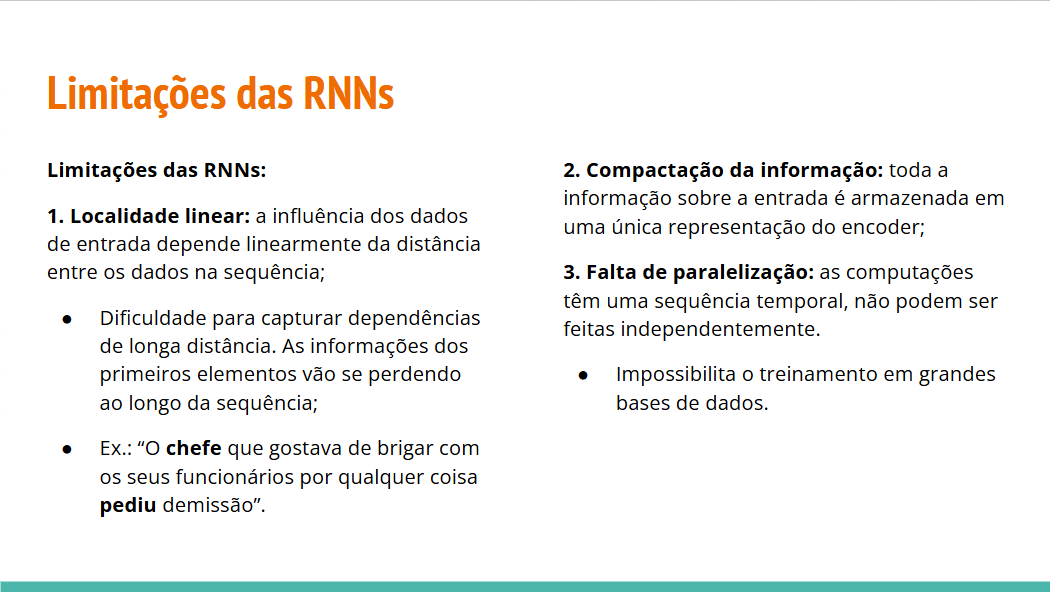

In [58]:
!git clone -b update-gluonts https://github.com/time-series-foundation-models/lag-llama/

Cloning into 'lag-llama'...
remote: Enumerating objects: 486, done.
remote: Counting objects: 100% (324/324), done.
remote: Compressing objects: 100% (151/151), done.
remote: Total 486 (delta 209), reused 260 (delta 169), pack-reused 162 (from 1)
Receiving objects: 100% (486/486), 271.18 KiB | 1.40 MiB/s, done.
Resolving deltas: 100% (250/250), done.


In [59]:
cd /content/lag-llama

/content/lag-llama


In [60]:
!pip install gluonts

In [61]:
!pip install lightning

In [62]:
!huggingface-cli download time-series-foundation-models/Lag-Llama lag-llama.ckpt --local-dir /content/lag-llama

/content/lag-llama/lag-llama.ckpt


In [63]:
from itertools import islice

from matplotlib import pyplot as plt
import matplotlib.dates as mdates

import torch
from gluonts.evaluation import make_evaluation_predictions, Evaluator
from gluonts.dataset.repository.datasets import get_dataset

from gluonts.dataset.pandas import PandasDataset
import pandas as pd

from lag_llama.gluon.estimator import LagLlamaEstimator

In [64]:
import sys
from types import ModuleType

# Create dummy module hierarchy
def create_dummy_module(module_path):
    """
    Create a dummy module hierarchy for the given path.
    Returns the leaf module.
    """
    parts = module_path.split('.')
    current = ''
    parent = None

    for part in parts:
        current = current + '.' + part if current else part
        if current not in sys.modules:
            module = ModuleType(current)
            sys.modules[current] = module
            if parent:
                setattr(sys.modules[parent], part, module)
        parent = current

    return sys.modules[module_path]

# Create the dummy gluonts module hierarchy
gluonts_module = create_dummy_module('gluonts.torch.modules.loss')

# Create dummy classes for the specific loss functions
class DistributionLoss:
    def __init__(self, *args, **kwargs):
        pass

    def __call__(self, *args, **kwargs):
        return 0.0

    def __getattr__(self, name):
        return lambda *args, **kwargs: None

class NegativeLogLikelihood:
    def __init__(self, *args, **kwargs):
        pass

    def __call__(self, *args, **kwargs):
        return 0.0

    def __getattr__(self, name):
        return lambda *args, **kwargs: None

# Add the specific classes to the module
gluonts_module.DistributionLoss = DistributionLoss
gluonts_module.NegativeLogLikelihood = NegativeLogLikelihood

In [65]:
def get_lag_llama_predictions(dataset, prediction_length, device, context_length=32, use_rope_scaling=False, num_samples=100):
    ckpt = torch.load("lag-llama.ckpt", map_location=device) # Uses GPU since in this Colab we use a GPU.
    estimator_args = ckpt["hyper_parameters"]["model_kwargs"]

    rope_scaling_arguments = {
        "type": "linear",
        "factor": max(1.0, (context_length + prediction_length) / estimator_args["context_length"]),
    }

    estimator = LagLlamaEstimator(
        ckpt_path="lag-llama.ckpt",
        prediction_length=prediction_length,
        context_length=context_length, # Lag-Llama was trained with a context length of 32, but can work with any context length

        # estimator args
        input_size=estimator_args["input_size"],
        n_layer=estimator_args["n_layer"],
        n_embd_per_head=estimator_args["n_embd_per_head"],
        n_head=estimator_args["n_head"],
        scaling=estimator_args["scaling"],
        time_feat=estimator_args["time_feat"],
        rope_scaling=rope_scaling_arguments if use_rope_scaling else None,

        batch_size=1,
        num_parallel_samples=100,
        device=device,
    )

    lightning_module = estimator.create_lightning_module()
    transformation = estimator.create_transformation()
    predictor = estimator.create_predictor(transformation, lightning_module)

    forecast_it, ts_it = make_evaluation_predictions(
        dataset=dataset,
        predictor=predictor,
        num_samples=num_samples
    )
    forecasts = list(forecast_it)
    tss = list(ts_it)

    return forecasts, tss

In [66]:
# Set the target column (replace 'T (degC)' with the actual target column name)
target_column = 'T (degC)'

# Rename the target column to "target"
train_df = train_df.rename(columns={target_column: "target"})
val_df = val_df.rename(columns={target_column: "target"})
test_df = test_df.rename(columns={target_column: "target"})

# Add a unique item_id for the time series
train_df["item_id"] = "series_1"
val_df["item_id"] = "series_1"
test_df["item_id"] = "series_1"

In [67]:
# Convert all numerical columns to float32
numeric_columns = train_df.select_dtypes(include=['float64', 'int']).columns
train_df[numeric_columns] = train_df[numeric_columns].astype('float32')
val_df[numeric_columns] = val_df[numeric_columns].astype('float32')
test_df[numeric_columns] = test_df[numeric_columns].astype('float32')

In [68]:
# Identify covariates (all columns except 'target' and 'item_id')
covariate_columns = [col for col in train_df.columns if col not in ["target", "item_id"]]

In [69]:
# Ensure feat_dynamic_real is structured as (number_of_covariates, time_steps)
train_feat_dynamic_real = train_df[covariate_columns].T.values.tolist()
val_feat_dynamic_real = val_df[covariate_columns].T.values.tolist()
test_feat_dynamic_real = test_df[covariate_columns].T.values.tolist()

# Assign the same covariates for all rows (for consistency with Lag-Llama)
train_df["feat_dynamic_real"] = [train_feat_dynamic_real] * len(train_df)
val_df["feat_dynamic_real"] = [val_feat_dynamic_real] * len(val_df)
test_df["feat_dynamic_real"] = [test_feat_dynamic_real] * len(test_df)

In [70]:
train_df

,p (mbar),target,Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),Wx,Wy,max Wx,max Wy,Day sin,Year sin,item_id,feat_dynamic_real
5,0.945308,-1.982473,-2.041888,-1.918973,1.117102,-1.302851,-1.477323,-0.790424,-1.480036,-1.482697,2.218524,0.193409,0.221161,0.111140,0.217928,0.366111,-0.061052,series_1,"[[0.9453076124191284, 0.9597698450088501, 0.98..."
11,0.959770,-2.078372,-2.138166,-2.060964,1.044617,-1.330143,-1.534354,-0.786272,-1.536190,-1.539034,2.325707,0.172987,0.222101,0.109458,0.227798,0.707200,-0.060029,series_1,"[[0.9453076124191284, 0.9597698450088501, 0.98..."
17,0.986284,-2.070284,-2.132436,-2.045187,1.062738,-1.328843,-1.527225,-0.788348,-1.528703,-1.531992,2.323998,0.207983,0.276266,0.111218,0.324078,1.000100,-0.059006,series_1,"[[0.9453076124191284, 0.9597698450088501, 0.98..."
23,1.004362,-2.098014,-2.161090,-2.096820,1.008375,-1.336640,-1.546235,-0.782121,-1.547421,-1.553119,2.358912,0.270343,0.195267,0.246907,0.145176,1.224850,-0.057983,series_1,"[[0.9453076124191284, 0.9597698450088501, 0.98..."
29,1.061006,-2.165028,-2.232152,-2.187178,0.984214,-1.353535,-1.579503,-0.782121,-1.581113,-1.585982,2.446320,0.112264,0.350818,0.048640,0.402053,1.366133,-0.056960,series_1,"[[0.9453076124191284, 0.9597698450088501, 0.98..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
294353,0.169167,0.904892,0.886564,1.571997,0.947972,0.776492,1.984916,-0.493604,1.979016,1.977352,-0.882480,-0.166720,-1.508412,-0.155728,-1.363530,-0.955374,-0.855026,series_1,"[[0.9453076124191284, 0.9597698450088501, 0.98..."
294359,0.266787,0.879473,0.853325,1.405624,0.621793,0.742703,1.680752,-0.283962,1.672043,1.672192,-0.822662,-0.824901,-0.641039,-0.704391,-0.475387,-0.652949,-0.855883,series_1,"[[0.9453076124191284, 0.9597698450088501, 0.98..."
294365,0.217374,0.740824,0.719223,1.425703,1.086900,0.559461,1.716396,-0.605690,1.709479,1.707403,-0.716211,-0.030746,0.645277,0.013960,0.600050,-0.306022,-0.856739,series_1,"[[0.9453076124191284, 0.9597698450088501, 0.98..."
294371,0.213759,0.710783,0.689423,1.412795,1.147303,0.521772,1.692633,-0.645127,1.687018,1.683929,-0.689842,0.014300,-0.102616,-0.095117,-0.198426,0.061765,-0.857595,series_1,"[[0.9453076124191284, 0.9597698450088501, 0.98..."


In [ ]:
# Inspect the first row of feat_dynamic_real
print(f"feat_dynamic_real (first row): {train_df['feat_dynamic_real'].iloc[0]}")
print(f"Number of covariates: {len(train_df['feat_dynamic_real'].iloc[0])}")  # Rows (covariates)
print(f"Number of time steps: {len(train_df['feat_dynamic_real'].iloc[0][0])}")  # Columns (time steps)

In [ ]:
# Check dimensions of feat_dynamic_real
print(f"Number of covariates: {len(train_df['feat_dynamic_real'][0])}")  # Rows
print(f"Number of time steps: {len(train_df['feat_dynamic_real'][0][0])}")  # Columns

KeyError: 0

In [ ]:
from gluonts.dataset.pandas import PandasDataset

train_dataset = PandasDataset.from_long_dataframe(
    train_df,
    target="target",
    item_id="item_id",
    feat_dynamic_real="feat_dynamic_real"
)

val_dataset = PandasDataset.from_long_dataframe(
    val_df,
    target="target",
    item_id="item_id",
    feat_dynamic_real="feat_dynamic_real"
)

test_dataset = PandasDataset.from_long_dataframe(
    test_df,
    target="target",
    item_id="item_id",
    feat_dynamic_real="feat_dynamic_real"
)


In [ ]:
# Prediction parameters
prediction_length = 1  # Number of timesteps to predict
context_length = 100  # Context length for Lag-Llama
num_samples = 32  # Number of probabilistic samples
device = torch.device("cuda:0")  # Use CPU if GPU is unavailable

# Run predictions on the test dataset
forecasts, tss = get_lag_llama_predictions(
    dataset=test_dataset,
    prediction_length=prediction_length,
    device=device,
    context_length=context_length,
    num_samples=num_samples
)

<ipython-input-50-4cfbdecae087>:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load("lag-llama.ckpt", map_location=device) # Uses GPU since in this Colab we u

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

MAE: 0.30993589758872986


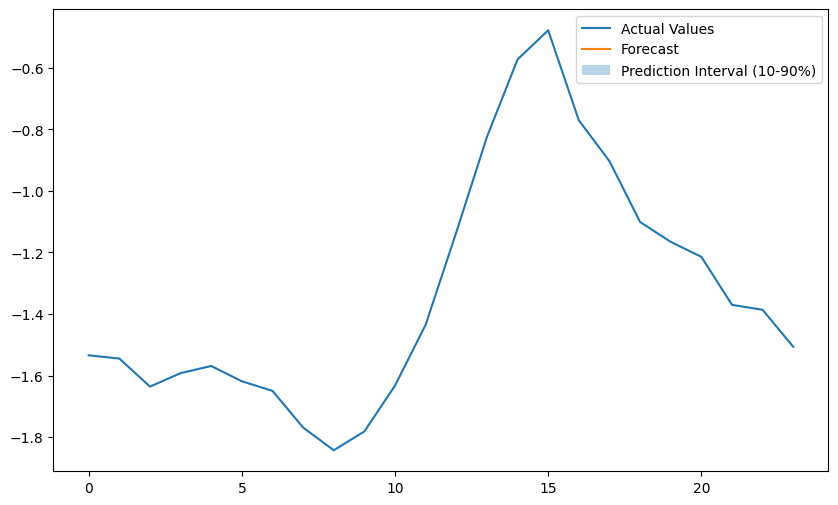

In [ ]:
# Step 5: Evaluate and visualize predictions
forecast_values = np.array([forecast.mean for forecast in forecasts])
actual_values = np.array([ts[-24:] for ts in tss])
mae = np.mean(np.abs(forecast_values - actual_values))
print(f"MAE: {mae}")

plt.figure(figsize=(10, 6))
plt.plot(actual_values[0], label="Actual Values")
plt.plot(forecast_values[0], label="Forecast")
plt.fill_between(
    range(len(forecast_values[0])),
    forecasts[0].quantile(0.1),
    forecasts[0].quantile(0.9),
    alpha=0.3,
    label="Prediction Interval (10-90%)"
)
plt.legend()